# RASIO Master Analysis

Notebook utama untuk menghasilkan analisis inti proyek RASIO secara berurutan. Jalankan dari atas ke bawah. Semua input dibaca dari `00_data/raw`, data olahan ditulis ke `00_data/processed`, dan grafik final disimpan di `02_visualizations/final`.

# 1. Clustering ketahanan pangan ASEAN

# Exploratory Clustering of ASEAN Rice-Supply Profiles

Notebook ini menyatukan data neraca beras AFSIS, perdagangan bilateral UN Comtrade, yield padi, RONI, dan batas administrasi negara menjadi satu **master dataframe tingkat negara**. Percobaan clustering dilakukan untuk $k=2$, $k=3$, dan $k=4$ menggunakan hierarchical clustering metode Ward.

## Keputusan metodologis utama

- Daftar ASEAN 2026 berisi **11 negara**, termasuk Timor-Leste yang resmi menjadi anggota ke-11 pada 26 Oktober 2025.
- Tabel AFSIS yang dilampirkan hanya mencakup 10 negara. Timor-Leste tetap dimasukkan ke master dataframe, tetapi tidak dipaksakan masuk clustering utama karena indikator domestic buffer belum tersedia.
- Clustering utama menggunakan dua indikator yang tersedia konsisten dan tidak mengulang informasi yang sama:
  1. `Production_Shortfall_pct`, yaitu bagian kebutuhan yang belum ditutup produksi domestik.
  2. `Beginning_Stock_to_Use_pct`, yaitu stok awal dibandingkan domestic utilization.
- `Import_Reliance_pct` tidak masuk model utama karena sangat berkorelasi dengan production shortfall. `Supplier_HHI` dan supplier climate exposure tetap dihitung, tetapi hanya menjadi diagnosis tambahan karena data perdagangan hanya mencakup empat reporter.
- Hasil disebut **exploratory structural profiles**, bukan prediksi krisis atau peringkat risiko pasti.

Sumber keanggotaan: https://asean.org/forging-a-new-era-timor-leste-admitted-into-asean/


## 1. Persiapan pustaka dan lokasi file

Cell berikut memuat pustaka analisis, menetapkan tampilan grafik, lalu mencari file pada dua lokasi: folder proyek Windows milikmu dan folder kerja tempat notebook dijalankan. Dengan cara ini, notebook tetap bisa digunakan di komputer lokal maupun setelah dipindahkan bersama file CSV.

Jika nama file mendapat tambahan seperti `(3)` atau `(4)`, fungsi `resolve_file()` tetap dapat menemukannya melalui pola nama.


In [1]:
from pathlib import Path
from io import StringIO
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import linregress, t as student_t
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

def find_project_root():
    """Temukan akar proyek dari folder kerja notebook saat ini."""
    start = Path.cwd().resolve()
    for folder in (start, *start.parents):
        if (folder / "00_data").exists() and (folder / "01_notebooks").exists():
            return folder
    raise FileNotFoundError("Folder akar proyek RASIO tidak ditemukan.")


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "00_data" / "raw"

RONI_PATH = RAW_DATA_DIR / "RONI_3_Months.csv"
TRADE_PATH = RAW_DATA_DIR / "TradeData_8_27_2026_21_50_21.csv"
YIELD_PATH = RAW_DATA_DIR / "rice-yields.csv"
SHP_PATH = (
    PROJECT_ROOT
    / "00_data"
    / "geospatial"
    / "ne_10m_admin_0_countries"
    / "ne_10m_admin_0_countries.shp"
)

print("RONI :", RONI_PATH)
print("Trade:", TRADE_PATH)
print("Yield:", YIELD_PATH)
print("SHP   :", SHP_PATH)


RONI : C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\raw\RONI_3_Months.csv
Trade: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\raw\TradeData_8_27_2026_21_50_21.csv
Yield: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\raw\rice-yields.csv
SHP   : C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\geospatial\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp


## 2. Menyusun data neraca beras AFSIS

Angka pada Table 7, Table 8, dan Table 9 yang kamu lampirkan ditranskripsikan menjadi data panjang `country-year`. Seluruh volume menggunakan ton beras giling. Setelah itu dilakukan pemeriksaan keseimbangan sederhana:

$$BeginningStock + Production + Import \approx Utilization + Export + EndingStock$$

Selisih satu ton masih dapat terjadi karena angka pada tabel dibulatkan. Tahun 2026 dipakai untuk profil utama karena merupakan horizon infografis, tetapi statusnya harus tetap ditulis sebagai proyeksi AFSIS.


In [2]:
afsis_csv = '''Year,Country,Beginning_Stock_ton,Production_ton,Import_ton,Domestic_Utilization_ton,Export_ton,Ending_Stock_ton
2024,Brunei Darussalam,8551,2348,29127,31097,0,8928
2024,Cambodia,2603849,8889320,0,7421155,645872,3426142
2024,Indonesia,4134399,34021974,4381671,34135743,24,8402277
2024,Lao PDR,56953,2250444,39632,2192061,45889,109079
2024,Malaysia,0,1317825,1686054,2900146,103733,0
2024,Myanmar,11356172,19209975,0,12360717,1841100,16364330
2024,Philippines,2100000,13154688,4780000,16597208,0,3437480
2024,Singapore,0,0,448295,260192,188103,0
2024,Thailand,6716104,21760946,12971,11039810,9987265,7462946
2024,Viet Nam,2775597,28239998,2936700,21475711,10158000,2318584
2025,Brunei Darussalam,8928,2613,25721,29487,0,7776
2025,Cambodia,3426142,9069846,0,7886894,665248,3943846
2025,Indonesia,8402277,38651626,532810,35057311,55,12529347
2025,Lao PDR,109079,2251398,34820,2287391,61683,46223
2025,Malaysia,0,1343880,1640914,2887728,97066,0
2025,Myanmar,16364330,19128054,0,13232275,1641188,20618921
2025,Philippines,3437480,12741675,4000000,17288305,0,2890850
2025,Singapore,0,0,538925,269267,269658,0
2025,Thailand,7462946,23137405,19389,11071810,8030000,11517930
2025,Viet Nam,2318584,28417620,3203906,21202316,10093000,2644794
2026,Brunei Darussalam,7776,2746,24048,29281,0,5289
2026,Cambodia,3943846,8960000,0,8096800,685206,4121841
2026,Indonesia,12529347,39260339,393131,31103146,804,21078867
2026,Lao PDR,46223,2382600,36258,2325052,54663,85367
2026,Malaysia,0,1357154,1634311,2889000,102465,0
2026,Myanmar,20618921,19023298,0,15405214,2110430,22126575
2026,Philippines,2890850,12791563,4000000,17471531,0,2210882
2026,Singapore,0,0,493610,264730,228880,0
2026,Thailand,11517930,23032393,20000,11079810,7530000,15960513
2026,Viet Nam,2644794,29319578,3203906,21518349,9562858,4087071
'''

afsis_long = pd.read_csv(StringIO(afsis_csv))

afsis_long["Supply_Total_ton"] = (
    afsis_long["Beginning_Stock_ton"]
    + afsis_long["Production_ton"]
    + afsis_long["Import_ton"]
)
afsis_long["Demand_Total_ton"] = (
    afsis_long["Domestic_Utilization_ton"]
    + afsis_long["Export_ton"]
    + afsis_long["Ending_Stock_ton"]
)
afsis_long["Balance_Error_ton"] = (
    afsis_long["Supply_Total_ton"] - afsis_long["Demand_Total_ton"]
)

afsis_long["SSR_pct"] = (
    afsis_long["Production_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)
afsis_long["Production_Shortfall_pct"] = (
    100 - afsis_long["SSR_pct"]
).clip(lower=0)
afsis_long["Import_Reliance_pct"] = (
    afsis_long["Import_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)
afsis_long["Beginning_Stock_to_Use_pct"] = (
    afsis_long["Beginning_Stock_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)
afsis_long["Ending_Stock_to_Use_pct"] = (
    afsis_long["Ending_Stock_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)

print("Jumlah observasi AFSIS:", len(afsis_long))
print("Maksimum selisih neraca akibat pembulatan:", int(afsis_long["Balance_Error_ton"].abs().max()), "ton")
print(
    afsis_long.query("Year == 2026")[[
        "Country", "SSR_pct", "Production_Shortfall_pct",
        "Import_Reliance_pct", "Beginning_Stock_to_Use_pct"
    ]].round(2).to_string(index=False)
)


Jumlah observasi AFSIS: 30
Maksimum selisih neraca akibat pembulatan: 1 ton
          Country  SSR_pct  Production_Shortfall_pct  Import_Reliance_pct  Beginning_Stock_to_Use_pct
Brunei Darussalam     9.38                     90.62                82.13                       26.56
         Cambodia   110.66                      0.00                 0.00                       48.71
        Indonesia   126.23                      0.00                 1.26                       40.28
          Lao PDR   102.48                      0.00                 1.56                        1.99
         Malaysia    46.98                     53.02                56.57                        0.00
          Myanmar   123.49                      0.00                 0.00                      133.84
      Philippines    73.21                     26.79                22.89                       16.55
        Singapore     0.00                    100.00               186.46                        0.00
      

## 3. Mengolah struktur pemasok dari UN Comtrade

Data perdagangan berisi HS 1006 untuk tahun 2024. Baris `World` dikeluarkan karena merupakan agregat, bukan pemasok. Supplier share dihitung dari `netWgt`, lalu diturunkan menjadi:

$$HHI_i = \sum_j s_{ij}^2$$

$$EffectiveSuppliers_i = \frac{1}{HHI_i}$$

HHI dan effective suppliers tidak digunakan bersamaan dalam clustering karena keduanya membawa informasi yang sama. Pada file yang tersedia, reporter hanya Brunei Darussalam, Malaysia, Philippines, dan Singapore.


In [3]:
# index_col=False diperlukan karena file ekspor memiliki delimiter kosong tambahan di akhir baris.
trade_raw = pd.read_csv(TRADE_PATH, index_col=False)

trade = trade_raw.copy()
trade["refYear"] = pd.to_numeric(trade["refYear"], errors="coerce")
trade["cmdCode"] = trade["cmdCode"].astype(str).str.replace(".0", "", regex=False)
trade["netWgt"] = pd.to_numeric(trade["netWgt"], errors="coerce")

trade_detail = trade.loc[
    trade["flowDesc"].eq("Import")
    & trade["refYear"].eq(2024)
    & trade["cmdCode"].eq("1006")
    & trade["partnerDesc"].ne("World")
    & trade["netWgt"].gt(0)
].copy()

trade_detail["Supplier_Share"] = trade_detail.groupby("reporterDesc")["netWgt"].transform(
    lambda s: s / s.sum()
)

def trade_summary_one(group):
    top_row = group.loc[group["Supplier_Share"].idxmax()]
    hhi = np.square(group["Supplier_Share"]).sum()
    return pd.Series({
        "Trade_Year": 2024,
        "Supplier_HHI": hhi,
        "Effective_Suppliers": 1 / hhi,
        "Top_Supplier": top_row["partnerDesc"],
        "Top_Supplier_Share_pct": top_row["Supplier_Share"] * 100,
        "Observed_Supplier_Count": group["partnerDesc"].nunique(),
        "Bilateral_Import_kg": group["netWgt"].sum(),
    })

trade_summary = (
    trade_detail.groupby("reporterDesc", group_keys=False)
    .apply(trade_summary_one, include_groups=False)
    .reset_index()
    .rename(columns={"reporterDesc": "Country"})
)

print("Reporter yang tersedia:", ", ".join(trade_summary["Country"]))
print(trade_summary.round(3).to_string(index=False))


Reporter yang tersedia: Brunei Darussalam, Malaysia, Philippines, Singapore
          Country  Trade_Year  Supplier_HHI  Effective_Suppliers Top_Supplier  Top_Supplier_Share_pct  Observed_Supplier_Count  Bilateral_Import_kg
Brunei Darussalam        2024         0.477                2.097     Thailand                  62.319                       12         3.128568e+07
         Malaysia        2024         0.270                3.699     Viet Nam                  40.561                       13         1.695310e+09
      Philippines        2024         0.578                1.730     Viet Nam                  74.423                       14         4.770089e+09
        Singapore        2024         0.291                3.434        India                  35.262                       26         4.485031e+08


## 4. Membersihkan RONI dan menghitung sensitivitas yield

File RONI memiliki header yang berulang setiap beberapa baris. Header tersebut dibuang, lalu 12 musim tiga-bulanan dirata-ratakan menjadi indikator RONI tahunan. Periode 1990 sampai 2023 digunakan agar seluruh negara produsen memiliki rentang yang sama dan tahun belum lengkap tidak ikut dianalisis.

Yield mentah tidak dibandingkan langsung karena perbedaan teknologi dan level produktivitas. Untuk setiap negara, notebook terlebih dahulu membentuk tren log-linear dan menghitung anomaly terhadap tren:

$$YieldAnomaly_{it}=\left(\frac{Yield_{it}}{TrendYield_{it}}-1\right)\times100$$

Kemudian anomaly diregresikan secara sederhana terhadap RONI tahunan. Koefisien negatif berarti yield secara historis cenderung lebih rendah ketika RONI meningkat. Hasil ini bersifat deskriptif, bukan hubungan kausal.


In [4]:
roni_raw = pd.read_csv(RONI_PATH, encoding="utf-8-sig")
roni = roni_raw.loc[pd.to_numeric(roni_raw["Year"], errors="coerce").notna()].copy()
roni["Year"] = pd.to_numeric(roni["Year"], errors="coerce").astype(int)

season_cols = [c for c in roni.columns if c != "Year"]
for col in season_cols:
    roni[col] = pd.to_numeric(roni[col], errors="coerce")

roni["RONI_Annual"] = roni[season_cols].mean(axis=1, skipna=True)
roni["RONI_Season_Count"] = roni[season_cols].notna().sum(axis=1)
roni_annual = roni[["Year", "RONI_Annual", "RONI_Season_Count"]].copy()

print("Rentang RONI bersih:", int(roni_annual["Year"].min()), "-", int(roni_annual["Year"].max()))
print("Baris tahun duplikat setelah header dibuang:", int(roni_annual["Year"].duplicated().sum()))
print(roni_annual.tail(8).round(3).to_string(index=False))


Rentang RONI bersih: 1950 - 2026
Baris tahun duplikat setelah header dibuang: 0
 Year  RONI_Annual  RONI_Season_Count
 2019        0.300                 12
 2020       -0.700                 12
 2021       -0.967                 12
 2022       -1.083                 12
 2023        0.358                 12
 2024       -0.242                 12
 2025       -0.725                 12
 2026       -0.100                  6


In [5]:
yield_raw = pd.read_csv(YIELD_PATH)
yield_value_col = next(c for c in yield_raw.columns if "yield" in c.lower() and c not in {"Entity", "Year"})

country_name_map = {
    "Brunei": "Brunei Darussalam",
    "East Timor": "Timor-Leste",
    "Laos": "Lao PDR",
    "Vietnam": "Viet Nam",
}

yield_clean = yield_raw.rename(columns={yield_value_col: "Rice_Yield_ton_per_ha"}).copy()
yield_clean["Country"] = yield_clean["Entity"].replace(country_name_map)
yield_clean["Year"] = pd.to_numeric(yield_clean["Year"], errors="coerce")
yield_clean["Rice_Yield_ton_per_ha"] = pd.to_numeric(
    yield_clean["Rice_Yield_ton_per_ha"], errors="coerce"
)
yield_clean = yield_clean.loc[
    yield_clean["Year"].between(1990, 2023)
    & yield_clean["Rice_Yield_ton_per_ha"].gt(0)
].copy()

yield_roni = yield_clean.merge(
    roni_annual.query("RONI_Season_Count == 12")[["Year", "RONI_Annual"]],
    on="Year",
    how="inner",
)

print("Negara yield:", ", ".join(sorted(yield_roni["Country"].unique())))
print("Periode analisis:", int(yield_roni["Year"].min()), "-", int(yield_roni["Year"].max()))
print(yield_roni.groupby("Country")["Year"].count().rename("n_years").to_string())


Negara yield: Brunei Darussalam, Cambodia, Indonesia, Lao PDR, Malaysia, Myanmar, Philippines, Thailand, Timor-Leste, Viet Nam
Periode analisis: 1990 - 2023
Country
Brunei Darussalam    34
Cambodia             34
Indonesia            34
Lao PDR              34
Malaysia             34
Myanmar              34
Philippines          34
Thailand             34
Timor-Leste          34
Viet Nam             34


In [6]:
climate_rows = []
yield_anomaly_parts = []

for country, group in yield_roni.groupby("Country"):
    g = group.dropna(subset=["Year", "Rice_Yield_ton_per_ha", "RONI_Annual"]).copy()
    years = g["Year"].to_numpy(dtype=float)
    observed = g["Rice_Yield_ton_per_ha"].to_numpy(dtype=float)

    trend_coef = np.polyfit(years, np.log(observed), deg=1)
    trend_yield = np.exp(np.polyval(trend_coef, years))
    anomaly = (observed / trend_yield - 1) * 100
    g["Yield_Anomaly_pct"] = anomaly
    yield_anomaly_parts.append(g)

    fit = linregress(g["RONI_Annual"], g["Yield_Anomaly_pct"])
    df_resid = len(g) - 2
    critical_t = student_t.ppf(0.975, df=df_resid)
    ci_low = fit.slope - critical_t * fit.stderr
    ci_high = fit.slope + critical_t * fit.stderr

    climate_rows.append({
        "Country": country,
        "Climate_n_years": len(g),
        "Yield_RONI_Beta_pp_per_1C": fit.slope,
        "Yield_RONI_CI_low": ci_low,
        "Yield_RONI_CI_high": ci_high,
        "Yield_RONI_pvalue": fit.pvalue,
        "Yield_RONI_R2": fit.rvalue ** 2,
        # Penalty hanya mengambil arah negatif. Nilai positif tidak dianggap loss.
        "Domestic_Climate_Penalty_pp_per_1C": max(0, -fit.slope),
    })

yield_anomaly = pd.concat(yield_anomaly_parts, ignore_index=True)
climate_sensitivity = pd.DataFrame(climate_rows).sort_values(
    "Domestic_Climate_Penalty_pp_per_1C", ascending=False
)
climate_sensitivity["Climate_Evidence"] = np.select(
    [
        (climate_sensitivity["Yield_RONI_Beta_pp_per_1C"] < 0)
        & (climate_sensitivity["Yield_RONI_pvalue"] < 0.05),
        climate_sensitivity["Yield_RONI_Beta_pp_per_1C"] < 0,
    ],
    ["Negative, p<0.05", "Negative, uncertain"],
    default="No negative association",
)

print(climate_sensitivity.round(3).to_string(index=False))


          Country  Climate_n_years  Yield_RONI_Beta_pp_per_1C  Yield_RONI_CI_low  Yield_RONI_CI_high  Yield_RONI_pvalue  Yield_RONI_R2  Domestic_Climate_Penalty_pp_per_1C        Climate_Evidence
         Cambodia               34                     -4.911             -8.883              -0.939              0.017          0.165                               4.911        Negative, p<0.05
         Viet Nam               34                     -1.159             -3.980               1.661              0.409          0.021                               1.159     Negative, uncertain
          Myanmar               34                     -1.110             -4.058               1.837              0.448          0.018                               1.110     Negative, uncertain
         Thailand               34                     -1.004             -5.114               3.107              0.622          0.008                               1.004     Negative, uncertain
Brunei Darussalam        

### Supplier-weighted climate exposure

Koefisien yield pemasok digabungkan dengan supplier share:

$$SupplierClimateExposure_i = \sum_j s_{ij}\max(0,-\beta_j)$$

Karena file yield hanya memuat negara ASEAN, beberapa pemasok besar dari luar kawasan seperti India dan Pakistan belum memiliki koefisien. Notebook menyimpan `Climate_Supplier_Coverage_pct` dan hanya menganggap exposure layak dipakai jika minimal 80% impor bilateral telah tercakup. Nilai di bawah ambang tidak diimputasi.


In [7]:
partner_name_map = {
    "Brunei": "Brunei Darussalam",
    "Lao PDR": "Lao PDR",
    "Viet Nam": "Viet Nam",
}

supplier_penalty = climate_sensitivity[[
    "Country", "Domestic_Climate_Penalty_pp_per_1C"
]].rename(columns={
    "Country": "Supplier_Country",
    "Domestic_Climate_Penalty_pp_per_1C": "Supplier_Climate_Penalty_pp_per_1C",
})

trade_climate = trade_detail.copy()
trade_climate["Supplier_Country"] = trade_climate["partnerDesc"].replace(partner_name_map)
trade_climate = trade_climate.merge(supplier_penalty, on="Supplier_Country", how="left")
trade_climate["Known_Climate_Contribution"] = (
    trade_climate["Supplier_Share"]
    * trade_climate["Supplier_Climate_Penalty_pp_per_1C"].fillna(0)
)
trade_climate["Known_Climate_Share"] = np.where(
    trade_climate["Supplier_Climate_Penalty_pp_per_1C"].notna(),
    trade_climate["Supplier_Share"],
    0,
)

supplier_exposure = (
    trade_climate.groupby("reporterDesc")
    .agg(
        Climate_Supplier_Coverage=("Known_Climate_Share", "sum"),
        Supplier_Climate_Exposure_partial=("Known_Climate_Contribution", "sum"),
    )
    .reset_index()
    .rename(columns={"reporterDesc": "Country"})
)
supplier_exposure["Climate_Supplier_Coverage_pct"] = (
    supplier_exposure["Climate_Supplier_Coverage"] * 100
)
supplier_exposure["Supplier_Climate_Exposure_pp_per_1C"] = np.where(
    supplier_exposure["Climate_Supplier_Coverage"] >= 0.80,
    supplier_exposure["Supplier_Climate_Exposure_partial"],
    np.nan,
)

print(supplier_exposure.round(3).to_string(index=False))


          Country  Climate_Supplier_Coverage  Supplier_Climate_Exposure_partial  Climate_Supplier_Coverage_pct  Supplier_Climate_Exposure_pp_per_1C
Brunei Darussalam                      0.917                              2.045                         91.738                                2.045
         Malaysia                      0.582                              0.802                         58.207                                  NaN
      Philippines                      0.923                              1.050                         92.326                                1.050
        Singapore                      0.603                              0.752                         60.348                                  NaN

## 5. Menggabungkan seluruh sumber menjadi satu master dataframe

Satu negara menjadi satu baris. Kolom `Eligible_Main_Cluster` menandai negara yang memiliki kedua indikator model utama. Timor-Leste dipertahankan agar dataframe benar-benar mengikuti daftar 11 anggota ASEAN 2026, sedangkan nilai yang belum tersedia dibiarkan `NaN`.

Perhatikan bahwa dataframe ini menggabungkan horizon berbeda:

- domestic balance dan stocks: proyeksi AFSIS 2026;
- struktur pemasok: UN Comtrade 2024;
- respons iklim: hubungan historis 1990 sampai 2023.

Karena itu, hasil dibaca sebagai profil struktural, bukan keadaan pada satu tahun observasi yang identik.


In [8]:
ASEAN_2026 = [
    "Brunei Darussalam", "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
    "Myanmar", "Philippines", "Singapore", "Thailand", "Timor-Leste", "Viet Nam",
]

roster = pd.DataFrame({
    "Country": ASEAN_2026,
    "ASEAN_Member_2026": True,
})

afsis_2026 = afsis_long.query("Year == 2026").copy()
afsis_2026 = afsis_2026.rename(columns={"Year": "AFSIS_Year"})
afsis_2026["AFSIS_Status"] = "Projection supplied in AFSIS Table 9-11"

master = (
    roster
    .merge(afsis_2026, on="Country", how="left")
    .merge(trade_summary, on="Country", how="left")
    .merge(climate_sensitivity, on="Country", how="left")
    .merge(supplier_exposure, on="Country", how="left")
)

master["Has_AFSIS_2026"] = master["AFSIS_Year"].notna()
master["Has_Trade_2024"] = master["Supplier_HHI"].notna()
master["Has_Domestic_Climate_Estimate"] = master["Yield_RONI_Beta_pp_per_1C"].notna()
master["Has_Validated_Supplier_Climate_Exposure"] = master[
    "Supplier_Climate_Exposure_pp_per_1C"
].notna()

MAIN_FEATURES = ["Production_Shortfall_pct", "Beginning_Stock_to_Use_pct"]
master["Eligible_Main_Cluster"] = master[MAIN_FEATURES].notna().all(axis=1)

master_columns = [
    "Country", "ASEAN_Member_2026", "AFSIS_Year", "AFSIS_Status",
    "Production_ton", "Domestic_Utilization_ton", "Import_ton", "Export_ton",
    "Beginning_Stock_ton", "Ending_Stock_ton", "SSR_pct",
    "Production_Shortfall_pct", "Import_Reliance_pct",
    "Beginning_Stock_to_Use_pct", "Ending_Stock_to_Use_pct",
    "Trade_Year", "Supplier_HHI", "Effective_Suppliers", "Top_Supplier",
    "Top_Supplier_Share_pct", "Observed_Supplier_Count",
    "Yield_RONI_Beta_pp_per_1C", "Yield_RONI_CI_low", "Yield_RONI_CI_high",
    "Yield_RONI_pvalue", "Yield_RONI_R2", "Domestic_Climate_Penalty_pp_per_1C",
    "Climate_Evidence", "Climate_Supplier_Coverage_pct",
    "Supplier_Climate_Exposure_partial", "Supplier_Climate_Exposure_pp_per_1C",
    "Has_AFSIS_2026", "Has_Trade_2024", "Has_Domestic_Climate_Estimate",
    "Has_Validated_Supplier_Climate_Exposure", "Eligible_Main_Cluster",
]
master = master[master_columns].sort_values("Country").reset_index(drop=True)

print("Ukuran master dataframe:", master.shape)
print("Eligible clustering utama:", int(master["Eligible_Main_Cluster"].sum()), "dari", len(master), "anggota")
print(master.round(3).to_string(index=False))


Ukuran master dataframe:

 (11, 36)
Eligible clustering utama: 10 dari 11 anggota
          Country  ASEAN_Member_2026  AFSIS_Year                            AFSIS_Status  Production_ton  Domestic_Utilization_ton  Import_ton  Export_ton  Beginning_Stock_ton  Ending_Stock_ton  SSR_pct  Production_Shortfall_pct  Import_Reliance_pct  Beginning_Stock_to_Use_pct  Ending_Stock_to_Use_pct  Trade_Year  Supplier_HHI  Effective_Suppliers Top_Supplier  Top_Supplier_Share_pct  Observed_Supplier_Count  Yield_RONI_Beta_pp_per_1C  Yield_RONI_CI_low  Yield_RONI_CI_high  Yield_RONI_pvalue  Yield_RONI_R2  Domestic_Climate_Penalty_pp_per_1C        Climate_Evidence  Climate_Supplier_Coverage_pct  Supplier_Climate_Exposure_partial  Supplier_Climate_Exposure_pp_per_1C  Has_AFSIS_2026  Has_Trade_2024  Has_Domestic_Climate_Estimate  Has_Validated_Supplier_Climate_Exposure  Eligible_Main_Cluster
Brunei Darussalam               True      2026.0 Projection supplied in AFSIS Table 9-11          2746.0                   29281.0     24048.0

## 6. Menyeleksi variabel agar tidak terjadi double counting

Sebelum clustering, notebook memeriksa korelasi indikator AFSIS yang lengkap. Aturan praktis yang digunakan adalah $|r| \geq 0.80$ sebagai tanda dua indikator sangat berdekatan informasinya.

- `Production_Shortfall_pct` dipertahankan karena langsung menjawab apakah produksi domestik mencukupi kebutuhan.
- `Import_Reliance_pct` hanya menjadi kolom deskriptif apabila korelasinya dengan shortfall terlalu tinggi.
- Beginning dan ending stock ratio tidak dipakai bersamaan. Beginning stock dipilih karena sesuai dengan food security ratio pada Table 11 dan menunjukkan buffer yang sudah tersedia pada awal periode.
- HHI dan climate exposure tidak masuk model utama karena cakupannya belum cukup untuk seluruh sampel.


In [9]:
main_sample = master.loc[master["Eligible_Main_Cluster"]].copy().reset_index(drop=True)

candidate_complete = [
    "Production_Shortfall_pct",
    "Import_Reliance_pct",
    "Beginning_Stock_to_Use_pct",
    "Ending_Stock_to_Use_pct",
]
corr = main_sample[candidate_complete].corr()

coverage_table = pd.DataFrame({
    "Indicator": [
        "Production_Shortfall_pct", "Import_Reliance_pct",
        "Beginning_Stock_to_Use_pct", "Ending_Stock_to_Use_pct",
        "Supplier_HHI", "Domestic_Climate_Penalty_pp_per_1C",
        "Supplier_Climate_Exposure_pp_per_1C",
    ],
    "Dimension": [
        "Domestic production adequacy", "Import dependence",
        "Available stock buffer", "Post-period stock buffer",
        "Supplier concentration", "Domestic climate response",
        "Imported supplier climate exposure",
    ],
})
coverage_table["Available_n_of_11"] = coverage_table["Indicator"].map(master.notna().sum())
coverage_table["Decision_Main_Model"] = [
    "Keep", "Descriptive: redundant with shortfall",
    "Keep", "Descriptive: redundant with beginning stock",
    "Descriptive: only four reporters", "Descriptive: Singapore missing",
    "Descriptive: coverage threshold met by only part of sample",
]

print("Korelasi indikator AFSIS:")
print(corr.round(3).to_string())
print("\nCakupan dan keputusan variabel:")
print(coverage_table.to_string(index=False))

shortfall_import_corr = corr.loc["Production_Shortfall_pct", "Import_Reliance_pct"]
stock_corr = corr.loc["Beginning_Stock_to_Use_pct", "Ending_Stock_to_Use_pct"]
assert abs(shortfall_import_corr) >= 0.80, "Periksa kembali keputusan redundansi shortfall dan import reliance."
assert abs(stock_corr) >= 0.80, "Periksa kembali keputusan redundansi beginning dan ending stocks."

print("\nVariabel final clustering:", MAIN_FEATURES)


Korelasi indikator AFSIS:
                            Production_Shortfall_pct  Import_Reliance_pct  Beginning_Stock_to_Use_pct  Ending_Stock_to_Use_pct
Production_Shortfall_pct                       1.000                0.921                      -0.454                   -0.518
Import_Reliance_pct                            0.921                1.000                      -0.454                   -0.486
Beginning_Stock_to_Use_pct                    -0.454               -0.454                       1.000                    0.976
Ending_Stock_to_Use_pct                       -0.518               -0.486                       0.976                    1.000

Cakupan dan keputusan variabel:
                          Indicator                          Dimension  Available_n_of_11                                        Decision_Main_Model
           Production_Shortfall_pct       Domestic production adequacy                 10                                                       Keep
        

## 7. Standardisasi

Walaupun kedua indikator sama-sama berupa persen, distribusinya sangat berbeda. Production shortfall memiliki banyak nilai nol, sedangkan stock-to-use memiliki nilai ekstrem di Myanmar dan Thailand. Karena itu digunakan `RobustScaler`:

$$X^{robust}=\frac{X-Median(X)}{IQR(X)}$$

Robust scaling mengurangi dominasi outlier. StandardScaler tetap dicoba kemudian sebagai sensitivity check.


Median asli: {'Production_Shortfall_pct': np.float64(0.0), 'Beginning_Stock_to_Use_pct': np.float64(21.551)}
IQR asli   : {'Production_Shortfall_pct': np.float64(46.464), 'Beginning_Stock_to_Use_pct': np.float64(42.039)}
          Country  z_Production_Shortfall_pct  z_Beginning_Stock_to_Use_pct
Brunei Darussalam                       1.950                         0.119
         Cambodia                       0.000                         0.646
        Indonesia                       0.000                         0.446
          Lao PDR                       0.000                        -0.465
         Malaysia                       1.141                        -0.513
          Myanmar                       0.000                         2.671
      Philippines                       0.576                        -0.119
        Singapore                       2.152                        -0.513
         Thailand                       0.000                         1.960
         Viet Nam  

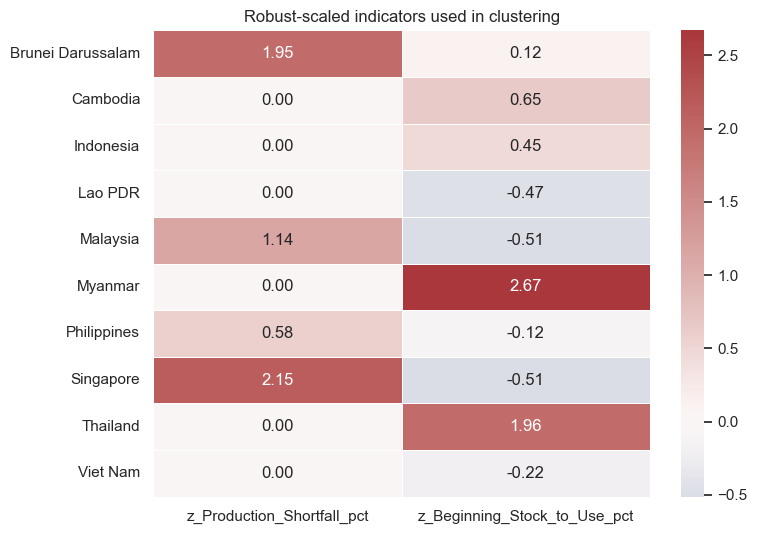

In [10]:
robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(main_sample[MAIN_FEATURES])

scaled_columns = [f"z_{c}" for c in MAIN_FEATURES]
scaled_df = pd.DataFrame(X_robust, columns=scaled_columns)
scaled_df.insert(0, "Country", main_sample["Country"])

print("Median asli:", dict(zip(MAIN_FEATURES, robust_scaler.center_.round(3))))
print("IQR asli   :", dict(zip(MAIN_FEATURES, robust_scaler.scale_.round(3))))
print(scaled_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    scaled_df.set_index("Country"), cmap="vlag", center=0,
    annot=True, fmt=".2f", linewidths=0.5, ax=ax
)
ax.set_title("Robust-scaled indicators used in clustering")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 8. Percobaan hierarchical clustering untuk $k=2$, $k=3$, dan $k=4$

Metode Ward dipilih karena jumlah negara kecil dan dendrogramnya mudah dijelaskan. Ward meminimalkan pertambahan variasi di dalam cluster pada setiap tahap penggabungan.

Tiga ukuran validasi dibandingkan:

- **Silhouette**: lebih tinggi lebih baik.
- **Calinski-Harabasz**: lebih tinggi lebih baik.
- **Davies-Bouldin**: lebih rendah lebih baik.

Ukuran cluster juga diperiksa. Nomor cluster diurutkan secara konsisten dari centroid dengan production gap lebih besar menuju buffer yang lebih kuat. Nomor tersebut tetap hanya ID, bukan peringkat risiko resmi.


In [11]:
def order_cluster_ids(raw_labels, frame):
    temp = frame[["Country"] + MAIN_FEATURES].copy()
    temp["raw_label"] = raw_labels
    centroids = temp.groupby("raw_label")[MAIN_FEATURES].mean()
    ordered_old_ids = centroids.sort_values(
        ["Production_Shortfall_pct", "Beginning_Stock_to_Use_pct"],
        ascending=[False, True],
    ).index.tolist()
    mapping = {old: f"C{rank + 1}" for rank, old in enumerate(ordered_old_ids)}
    return pd.Series(raw_labels).map(mapping).to_numpy()

cluster_models = {}
metric_rows = []

for k in [2, 3, 4]:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    raw_labels = model.fit_predict(X_robust)
    ordered_labels = order_cluster_ids(raw_labels, main_sample)
    cluster_models[k] = {
        "model": model,
        "raw_labels": raw_labels,
        "labels": ordered_labels,
    }
    sizes = pd.Series(ordered_labels).value_counts()
    metric_rows.append({
        "k": k,
        "Silhouette": silhouette_score(X_robust, raw_labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_robust, raw_labels),
        "Davies_Bouldin": davies_bouldin_score(X_robust, raw_labels),
        "Minimum_Cluster_Size": int(sizes.min()),
        "Maximum_Cluster_Size": int(sizes.max()),
        "Has_Singleton": bool((sizes == 1).any()),
    })
    main_sample[f"Cluster_k{k}"] = ordered_labels

cluster_metrics = pd.DataFrame(metric_rows)
print(cluster_metrics.round(4).to_string(index=False))

membership_table = main_sample[["Country", "Cluster_k2", "Cluster_k3", "Cluster_k4"]]
print("\nKeanggotaan cluster:")
print(membership_table.to_string(index=False))


 k  Silhouette  Calinski_Harabasz  Davies_Bouldin  Minimum_Cluster_Size  Maximum_Cluster_Size  Has_Singleton
 2      0.5355            10.7117          0.4906                     2                     8          False
 3      0.5278            18.6338          0.4707                     2                     6          False
 4      0.4714            21.3457          0.4936                     2                     4          False

Keanggotaan cluster:
          Country Cluster_k2 Cluster_k3 Cluster_k4
Brunei Darussalam         C1         C1         C1
         Cambodia         C1         C2         C3
        Indonesia         C1         C2         C3
          Lao PDR         C1         C2         C2
         Malaysia         C1         C2         C2
          Myanmar         C2         C3         C4
      Philippines         C1         C2         C2
        Singapore         C1         C1         C1
         Thailand         C2         C3         C4
         Viet Nam         C1    

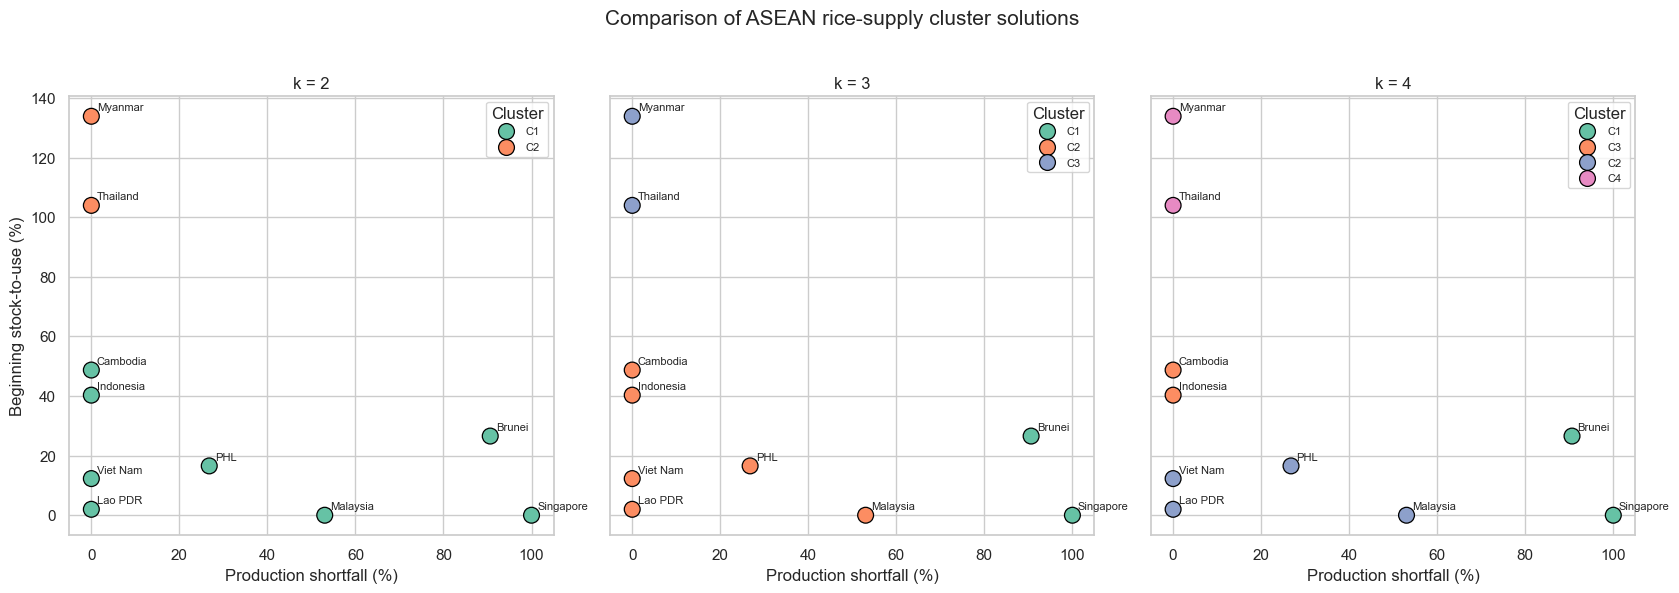

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.8), sharex=True, sharey=True)

for ax, k in zip(axes, [2, 3, 4]):
    cluster_col = f"Cluster_k{k}"
    sns.scatterplot(
        data=main_sample,
        x="Production_Shortfall_pct",
        y="Beginning_Stock_to_Use_pct",
        hue=cluster_col,
        palette="Set2",
        s=130,
        edgecolor="black",
        ax=ax,
    )
    for _, row in main_sample.iterrows():
        label = row["Country"].replace("Brunei Darussalam", "Brunei").replace("Philippines", "PHL")
        ax.annotate(label, (row["Production_Shortfall_pct"], row["Beginning_Stock_to_Use_pct"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Production shortfall (%)")
    ax.set_ylabel("Beginning stock-to-use (%)")
    ax.legend(title="Cluster", fontsize=8)

fig.suptitle("Comparison of ASEAN rice-supply cluster solutions", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()


## 9. Dendrogram

Dendrogram memperlihatkan urutan negara digabungkan berdasarkan kemiripan indikator. Cabang yang bertemu pada ketinggian rendah berarti profilnya lebih mirip. Dendrogram membantu melihat apakah pemotongan menjadi dua, tiga, atau empat cluster didukung oleh jarak yang cukup jelas.


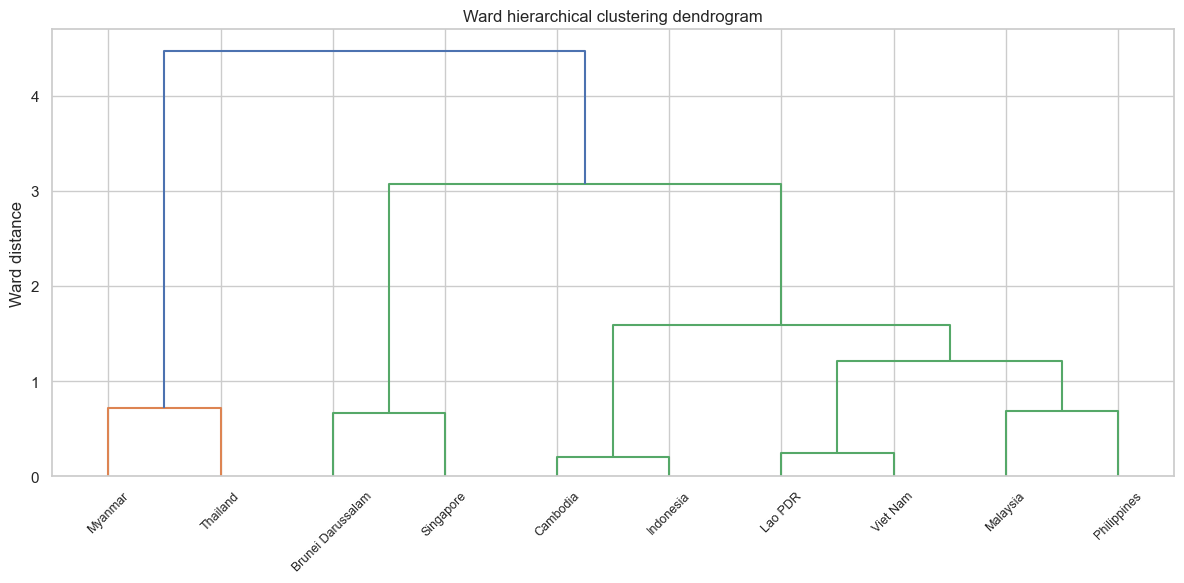

In [13]:
Z = linkage(X_robust, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z,
    labels=main_sample["Country"].tolist(),
    leaf_rotation=45,
    leaf_font_size=9,
    color_threshold=None,
    ax=ax,
)
ax.set_title("Ward hierarchical clustering dendrogram")
ax.set_ylabel("Ward distance")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 10. Sensitivity check terhadap metode standardisasi

Cluster dihitung ulang dengan StandardScaler. Kesamaan hasil RobustScaler dan StandardScaler dinilai menggunakan Adjusted Rand Index (ARI):

- ARI mendekati 1 berarti keanggotaan sangat konsisten;
- ARI mendekati 0 berarti kesamaannya tidak lebih baik dari kebetulan;
- nilai rendah untuk $k=4$ menunjukkan solusi empat cluster sensitif terhadap cara data distandarkan.


In [14]:
X_standard = StandardScaler().fit_transform(main_sample[MAIN_FEATURES])
scaling_stability = []

for k in [2, 3, 4]:
    robust_raw = cluster_models[k]["raw_labels"]
    standard_raw = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_standard)
    scaling_stability.append({
        "k": k,
        "Adjusted_Rand_Index_Robust_vs_Standard": adjusted_rand_score(robust_raw, standard_raw),
    })

scaling_stability = pd.DataFrame(scaling_stability)
cluster_metrics = cluster_metrics.merge(scaling_stability, on="k", how="left")

# Multi-criteria rank sederhana. Nilai lebih kecil lebih baik.
cluster_metrics["Rank_Silhouette"] = cluster_metrics["Silhouette"].rank(ascending=False, method="min")
cluster_metrics["Rank_CH"] = cluster_metrics["Calinski_Harabasz"].rank(ascending=False, method="min")
cluster_metrics["Rank_DB"] = cluster_metrics["Davies_Bouldin"].rank(ascending=True, method="min")
cluster_metrics["Composite_Rank_Sum"] = cluster_metrics[[
    "Rank_Silhouette", "Rank_CH", "Rank_DB"
]].sum(axis=1)

recommended_k = int(
    cluster_metrics.sort_values(
        ["Composite_Rank_Sum", "Adjusted_Rand_Index_Robust_vs_Standard", "k"],
        ascending=[True, False, True],
    ).iloc[0]["k"]
)

print(cluster_metrics.round(4).to_string(index=False))
print(f"\nSolusi kerja yang direkomendasikan notebook: k = {recommended_k}")
print("Rekomendasi tetap eksploratif karena n hanya", len(main_sample), "negara.")


 k  Silhouette  Calinski_Harabasz  Davies_Bouldin  Minimum_Cluster_Size  Maximum_Cluster_Size  Has_Singleton  Adjusted_Rand_Index_Robust_vs_Standard  Rank_Silhouette  Rank_CH  Rank_DB  Composite_Rank_Sum
 2      0.5355            10.7117          0.4906                     2                     8          False                                  1.0000              1.0      3.0      2.0                 6.0
 3      0.5278            18.6338          0.4707                     2                     6          False                                  1.0000              2.0      2.0      1.0                 5.0
 4      0.4714            21.3457          0.4936                     2                     4          False                                  0.4444              3.0      1.0      3.0                 7.0

Solusi kerja yang direkomendasikan notebook: k = 3
Rekomendasi tetap eksploratif karena n hanya 10 negara.


## 11. Membentuk profil cluster terpilih

Nama profil dibuat **setelah** cluster terbentuk, berdasarkan centroid production shortfall dan stock-to-use. Nama ini membantu pembaca memahami pola rata-rata, tetapi tidak mengubah perhitungan algoritma.


In [15]:
selected_cluster_col = f"Cluster_k{recommended_k}"

def descriptive_profile_name(row):
    gap = row["Mean_Production_Shortfall_pct"]
    stock = row["Mean_Beginning_Stock_to_Use_pct"]
    if gap >= 60 and stock < 30:
        return "Large domestic gap, limited stocks"
    if gap >= 60:
        return "Large domestic gap, stock-supported"
    if gap >= 10 and stock < 30:
        return "Mixed or partial gap, limited stocks"
    if gap >= 10:
        return "Mixed or partial gap, stock-supported"
    if stock >= 75:
        return "Domestic surplus, deep stocks"
    if stock >= 25:
        return "Domestic surplus, moderate stocks"
    return "Domestic surplus, limited stocks"

cluster_profiles = (
    main_sample.groupby(selected_cluster_col)
    .agg(
        Countries=("Country", "size"),
        Mean_Production_Shortfall_pct=("Production_Shortfall_pct", "mean"),
        Mean_Beginning_Stock_to_Use_pct=("Beginning_Stock_to_Use_pct", "mean"),
        Mean_SSR_pct=("SSR_pct", "mean"),
        Country_List=("Country", lambda s: ", ".join(sorted(s))),
    )
    .reset_index()
)
cluster_profiles["Profile_Name"] = cluster_profiles.apply(descriptive_profile_name, axis=1)

profile_name_map = cluster_profiles.set_index(selected_cluster_col)["Profile_Name"]
main_sample["Selected_Cluster"] = main_sample[selected_cluster_col]
main_sample["Selected_Profile"] = main_sample["Selected_Cluster"].map(profile_name_map)

master = master.merge(
    main_sample[["Country", "Cluster_k2", "Cluster_k3", "Cluster_k4", "Selected_Cluster", "Selected_Profile"]],
    on="Country",
    how="left",
)

print(cluster_profiles.round(2).to_string(index=False))
print("\nHasil per negara:")
print(main_sample[["Country", "Selected_Cluster", "Selected_Profile"]].to_string(index=False))


Cluster_k3  Countries  Mean_Production_Shortfall_pct  Mean_Beginning_Stock_to_Use_pct  Mean_SSR_pct                                                  Country_List                         Profile_Name
        C1          2                          95.31                            13.28          4.69                                  Brunei Darussalam, Singapore   Large domestic gap, limited stocks
        C2          6                          13.30                            19.97         99.30 Cambodia, Indonesia, Lao PDR, Malaysia, Philippines, Viet Nam Mixed or partial gap, limited stocks
        C3          2                           0.00                           118.90        165.68                                             Myanmar, Thailand        Domestic surplus, deep stocks

Hasil per negara:
          Country Selected_Cluster                     Selected_Profile
Brunei Darussalam               C1   Large domestic gap, limited stocks
         Cambodia               C2 Mixed 

In [16]:
def descriptive_profile_name(row):
    gap = row["Mean_Production_Shortfall_pct"]
    stock = row["Mean_Beginning_Stock_to_Use_pct"]

    if gap >= 60 and stock < 30:
        return "Large domestic gap, limited stocks"
    if gap >= 60:
        return "Large domestic gap, stock-supported"
    if gap >= 10 and stock < 30:
        return "Mixed or partial gap, limited stocks"
    if gap >= 10:
        return "Mixed or partial gap, stock-supported"
    if stock >= 75:
        return "Domestic surplus, deep stocks"
    if stock >= 25:
        return "Domestic surplus, moderate stocks"

    return "Domestic surplus, limited stocks"


# Menyimpan profil seluruh percobaan cluster
all_cluster_profiles = []

for k in [2, 3, 4]:
    cluster_col = f"Cluster_k{k}"

    profiles_k = (
        main_sample.groupby(cluster_col)
        .agg(
            Countries=("Country", "size"),
            Mean_Production_Shortfall_pct=(
                "Production_Shortfall_pct", "mean"
            ),
            Mean_Beginning_Stock_to_Use_pct=(
                "Beginning_Stock_to_Use_pct", "mean"
            ),
            Mean_SSR_pct=("SSR_pct", "mean"),
            Country_List=(
                "Country",
                lambda s: ", ".join(sorted(s))
            ),
        )
        .reset_index()
        .rename(columns={cluster_col: "Cluster"})
    )

    # Menambahkan informasi jumlah cluster
    profiles_k.insert(0, "k", k)

    # Menandai cluster yang hanya berisi satu negara
    profiles_k["Is_Singleton"] = profiles_k["Countries"].eq(1)

    # Memberikan nama profil berdasarkan karakteristik rata-rata cluster
    profiles_k["Profile_Name"] = profiles_k.apply(
        descriptive_profile_name,
        axis=1
    )

    # Memasukkan nama profil ke main_sample
    profile_name_map_k = profiles_k.set_index(
        "Cluster"
    )["Profile_Name"].to_dict()

    main_sample[f"Profile_k{k}"] = (
        main_sample[cluster_col].map(profile_name_map_k)
    )

    all_cluster_profiles.append(profiles_k)


# Menggabungkan profil k=2, k=3, dan k=4
all_cluster_profiles = pd.concat(
    all_cluster_profiles,
    ignore_index=True
)


# =========================================================
# OUTPUT 1: Ringkasan seluruh cluster
# =========================================================

print("RINGKASAN PROFIL CLUSTER K=2, K=3, DAN K=4\n")

print(
    all_cluster_profiles[
        [
            "k",
            "Cluster",
            "Countries",
            "Is_Singleton",
            "Mean_Production_Shortfall_pct",
            "Mean_Beginning_Stock_to_Use_pct",
            "Mean_SSR_pct",
            "Profile_Name",
            "Country_List",
        ]
    ]
    .round(2)
    .to_string(index=False)
)


# =========================================================
# OUTPUT 2: Keanggotaan cluster setiap negara
# =========================================================

print("\n\nKEANGGOTAAN CLUSTER SETIAP NEGARA\n")

membership_comparison = (
    main_sample[
        [
            "Country",
            "Cluster_k2",
            "Cluster_k3",
            "Cluster_k4",
        ]
    ]
    .sort_values("Country")
    .reset_index(drop=True)
)

print(membership_comparison.to_string(index=False))


# =========================================================
# OUTPUT 3: Pemeriksaan singleton cluster
# =========================================================

print("\n\nPEMERIKSAAN CLUSTER BERISI SATU NEGARA\n")

for k in [2, 3, 4]:
    singleton_clusters = all_cluster_profiles.loc[
        (all_cluster_profiles["k"] == k)
        & (all_cluster_profiles["Is_Singleton"]),
        ["Cluster", "Country_List"]
    ]

    if singleton_clusters.empty:
        print(f"k={k}: Tidak ada singleton cluster.")
    else:
        print(f"k={k}: Ada singleton cluster:")
        for _, row in singleton_clusters.iterrows():
            print(
                f"  {row['Cluster']}: "
                f"{row['Country_List']}"
            )


# =========================================================
# Mempertahankan hasil cluster yang direkomendasikan
# untuk digunakan pada cell berikutnya
# =========================================================

selected_cluster_col = f"Cluster_k{recommended_k}"
selected_profile_col = f"Profile_k{recommended_k}"

main_sample["Selected_Cluster"] = (
    main_sample[selected_cluster_col]
)

main_sample["Selected_Profile"] = (
    main_sample[selected_profile_col]
)

# cluster_profiles tetap disediakan agar kompatibel
# dengan cell penyimpanan sebelumnya
cluster_profiles = (
    all_cluster_profiles.loc[
        all_cluster_profiles["k"] == recommended_k
    ]
    .drop(columns="k")
    .rename(columns={"Cluster": selected_cluster_col})
    .reset_index(drop=True)
)


# Menghindari kolom duplikat jika cell dijalankan ulang
columns_to_merge = [
    "Cluster_k2",
    "Cluster_k3",
    "Cluster_k4",
    "Selected_Cluster",
    "Selected_Profile",
]

master = master.drop(
    columns=[
        col for col in columns_to_merge
        if col in master.columns
    ],
    errors="ignore"
)

master = master.merge(
    main_sample[
        [
            "Country",
            "Cluster_k2",
            "Cluster_k3",
            "Cluster_k4",
            "Selected_Cluster",
            "Selected_Profile",
        ]
    ],
    on="Country",
    how="left",
)

RINGKASAN PROFIL CLUSTER K=2, K=3, DAN K=4

 k Cluster  Countries  Is_Singleton  Mean_Production_Shortfall_pct  Mean_Beginning_Stock_to_Use_pct  Mean_SSR_pct                         Profile_Name                                                                                Country_List
 2      C1          8         False                          33.80                            18.30         75.65 Mixed or partial gap, limited stocks Brunei Darussalam, Cambodia, Indonesia, Lao PDR, Malaysia, Philippines, Singapore, Viet Nam
 2      C2          2         False                           0.00                           118.90        165.68        Domestic surplus, deep stocks                                                                           Myanmar, Thailand
 3      C1          2         False                          95.31                            13.28          4.69   Large domestic gap, limited stocks                                                                Brunei Daruss

## 12. Diagnosis tambahan dari data climate dan supplier concentration

Tabel ini tidak membentuk cluster utama. Tujuannya menunjukkan informasi tambahan yang sudah berhasil dihitung dan bagian yang masih terbatas cakupannya.

Koefisien climate dengan interval lebar atau $p \geq 0.05$ tidak boleh ditulis sebagai bukti dampak yang pasti. Demikian juga, HHI hanya tersedia untuk empat reporter sehingga belum layak dipaksakan ke seluruh ASEAN.


In [17]:
diagnostic_columns = [
    "Country", "Supplier_HHI", "Effective_Suppliers", "Top_Supplier",
    "Top_Supplier_Share_pct", "Yield_RONI_Beta_pp_per_1C", "Yield_RONI_pvalue",
    "Climate_Evidence", "Climate_Supplier_Coverage_pct",
    "Supplier_Climate_Exposure_pp_per_1C",
]
print(master[diagnostic_columns].round(3).to_string(index=False))

print("\nCatatan:")
print("- HHI tersedia untuk", int(master["Supplier_HHI"].notna().sum()), "negara reporter.")
print("- Supplier climate exposure lolos coverage >=80% untuk", int(master["Supplier_Climate_Exposure_pp_per_1C"].notna().sum()), "negara.")
print("- Estimasi respons yield domestik tersedia untuk", int(master["Yield_RONI_Beta_pp_per_1C"].notna().sum()), "negara.")


          Country  Supplier_HHI  Effective_Suppliers Top_Supplier  Top_Supplier_Share_pct  Yield_RONI_Beta_pp_per_1C  Yield_RONI_pvalue        Climate_Evidence  Climate_Supplier_Coverage_pct  Supplier_Climate_Exposure_pp_per_1C
Brunei Darussalam         0.477                2.097     Thailand                  62.319                      7.811              0.396 No negative association                         91.738                                2.045
         Cambodia           NaN                  NaN          NaN                     NaN                     -4.911              0.017        Negative, p<0.05                            NaN                                  NaN
        Indonesia           NaN                  NaN          NaN                     NaN                      1.544              0.043 No negative association                            NaN                                  NaN
          Lao PDR           NaN                  NaN          NaN                     Na

## 13. Peta cluster ASEAN

Shapefile bukan satu file tunggal. Agar dapat dibaca, paling tidak komponen `.shp`, `.shx`, dan `.dbf` harus berada pada folder yang sama dengan nama dasar identik. File `.prj` juga sebaiknya tersedia agar sistem koordinat terbaca dengan benar.

Cell akan menggunakan path milikmu:

`C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp`

Jika komponen atau `geopandas` belum tersedia, analisis lain tetap berjalan dan cell hanya menampilkan petunjuk perbaikan.


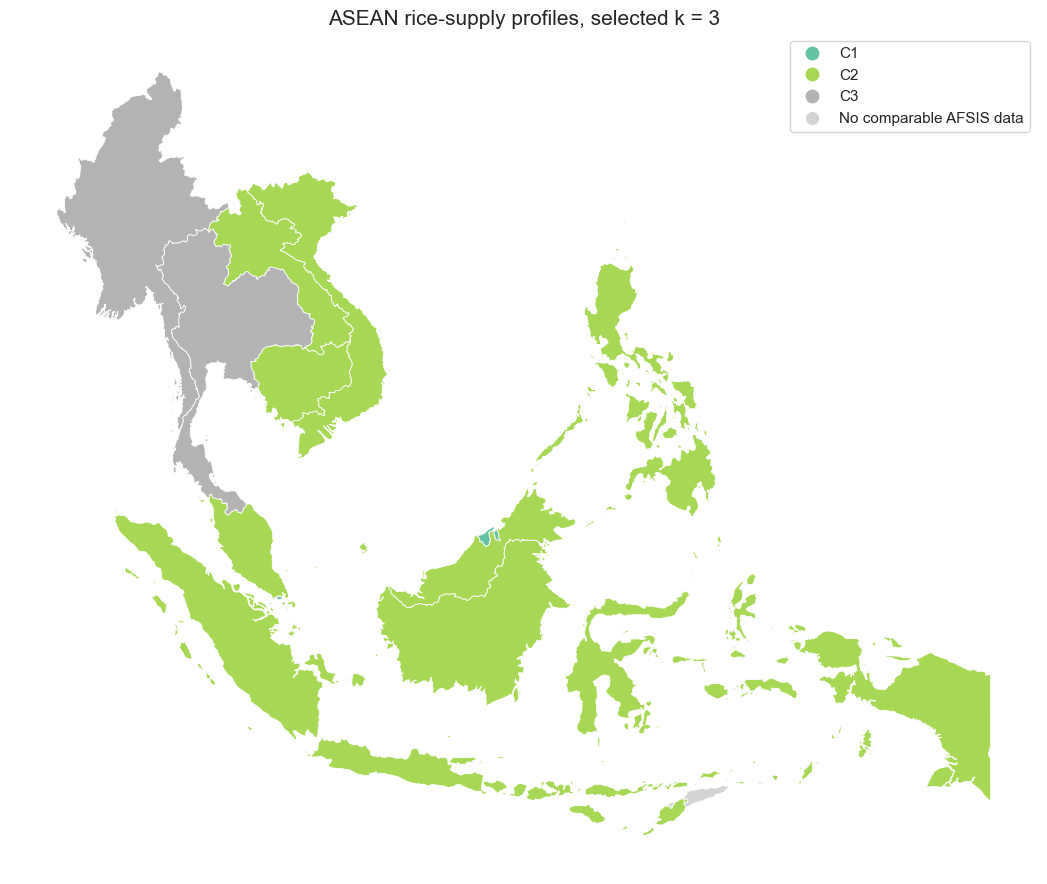

Peta berhasil dibuat untuk 11 geometri negara ASEAN.


In [18]:
required_sidecars = [SHP_PATH.with_suffix(".shx"), SHP_PATH.with_suffix(".dbf")]
missing_sidecars = [str(p) for p in required_sidecars if not p.exists()]
map_was_created = False

if not SHP_PATH.exists():
    print("Peta dilewati: file .shp tidak ditemukan pada path yang diperiksa.")
elif missing_sidecars:
    print("Peta dilewati karena komponen shapefile belum lengkap:")
    for item in missing_sidecars:
        print(" -", item)
    print("Salin seluruh isi folder Natural Earth, bukan hanya file .shp.")
else:
    try:
        import geopandas as gpd

        world = gpd.read_file(SHP_PATH)
        name_candidates = ["ADMIN", "SOVEREIGNT", "NAME", "NAME_EN", "FORMAL_EN"]
        name_col = next((c for c in name_candidates if c in world.columns), None)
        if name_col is None:
            raise KeyError(f"Kolom nama negara tidak ditemukan. Kolom tersedia: {world.columns.tolist()}")

        geo_name_map = {
            "Brunei": "Brunei Darussalam",
            "East Timor": "Timor-Leste",
            "Lao PDR": "Lao PDR",
            "Laos": "Lao PDR",
            "Vietnam": "Viet Nam",
        }
        world["Country"] = world[name_col].replace(geo_name_map)
        asean_geo = world.loc[world["Country"].isin(ASEAN_2026)].copy()
        asean_geo = asean_geo.merge(
            master[["Country", "Selected_Cluster", "Selected_Profile"]],
            on="Country", how="left"
        )

        fig, ax = plt.subplots(figsize=(11, 9))
        asean_geo.plot(
            column="Selected_Cluster",
            categorical=True,
            cmap="Set2",
            linewidth=0.6,
            edgecolor="white",
            legend=True,
            missing_kwds={"color": "lightgrey", "label": "No comparable AFSIS data"},
            ax=ax,
        )
        ax.set_title(f"ASEAN rice-supply profiles, selected k = {recommended_k}", fontsize=15)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()
        map_was_created = True
        print("Peta berhasil dibuat untuk", len(asean_geo), "geometri negara ASEAN.")
    except ImportError:
        print("Peta dilewati: geopandas belum terpasang.")
        print("Jalankan `%pip install geopandas pyogrio` pada environment notebook, lalu ulangi cell ini.")
    except Exception as exc:
        print("Peta belum dapat dibuat:", repr(exc))


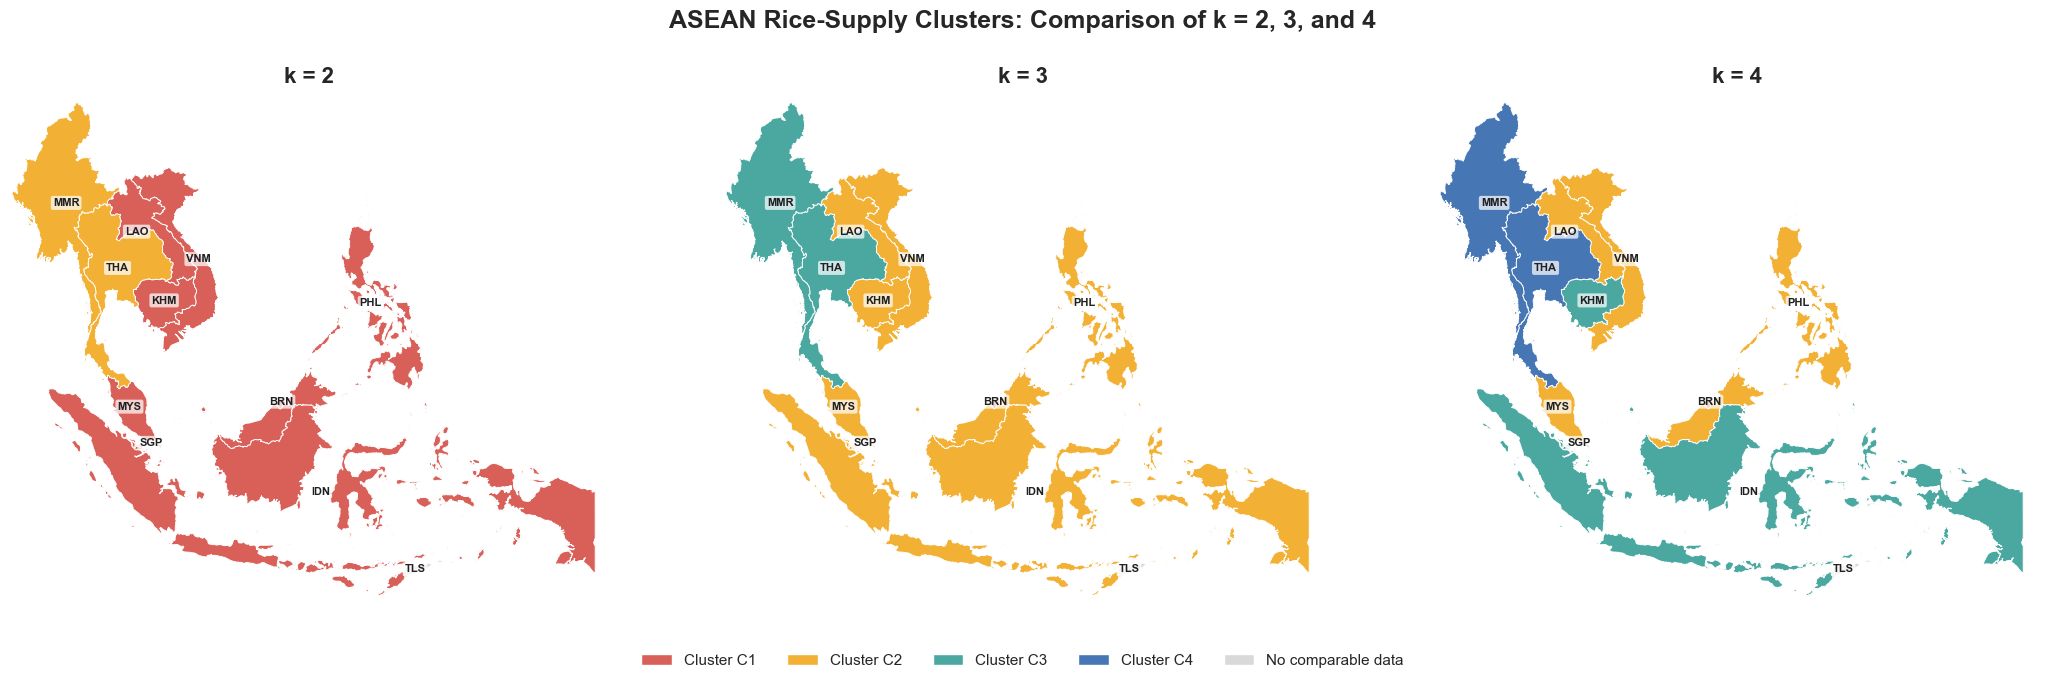

In [19]:
# Peta perbandingan hasil clustering.
# Gunakan [2, 3, 4] untuk membandingkan semua solusi, atau misalnya [3] untuk satu peta saja.
MAP_K_VALUES = [2, 3, 4]

from matplotlib.patches import Patch

cluster_colors = {
    "C1": "#D95F59",
    "C2": "#F2B134",
    "C3": "#4AA8A1",
    "C4": "#4776B4",
}
no_data_color = "#D9D9D9"

# Posisi label dibuat manual agar negara kecil dan kepulauan tetap mudah dibaca.
label_positions = {
    "Brunei Darussalam": (114.7, 4.6, "BRN"),
    "Cambodia": (104.9, 12.7, "KHM"),
    "Indonesia": (118.0, -2.6, "IDN"),
    "Lao PDR": (102.6, 18.2, "LAO"),
    "Malaysia": (102.0, 4.2, "MYS"),
    "Myanmar": (96.7, 20.5, "MMR"),
    "Philippines": (122.2, 12.5, "PHL"),
    "Singapore": (103.8, 1.3, "SGP"),
    "Thailand": (101.0, 15.3, "THA"),
    "Timor-Leste": (125.9, -8.8, "TLS"),
    "Viet Nam": (107.8, 16.0, "VNM"),
}

required_sidecars = [SHP_PATH.with_suffix(".shx"), SHP_PATH.with_suffix(".dbf")]
missing_sidecars = [p for p in required_sidecars if not p.exists()]

if not SHP_PATH.exists() or missing_sidecars:
    print("Peta belum dapat dibuat. Pastikan file .shp, .shx, dan .dbf berada dalam folder yang sama.")
    print("Path yang diperiksa:", SHP_PATH)
else:
    try:
        import geopandas as gpd

        world_map = gpd.read_file(SHP_PATH)
        name_candidates = ["ADMIN", "SOVEREIGNT", "NAME", "NAME_EN", "FORMAL_EN"]
        name_col = next((c for c in name_candidates if c in world_map.columns), None)
        if name_col is None:
            raise KeyError(f"Kolom nama negara tidak ditemukan. Kolom tersedia: {world_map.columns.tolist()}")

        geo_name_map = {
            "Brunei": "Brunei Darussalam",
            "East Timor": "Timor-Leste",
            "Laos": "Lao PDR",
            "Vietnam": "Viet Nam",
        }
        world_map["Country"] = world_map[name_col].replace(geo_name_map)
        asean_map = world_map.loc[world_map["Country"].isin(ASEAN_2026)].copy()
        asean_map = asean_map.merge(
            master[["Country", "Cluster_k2", "Cluster_k3", "Cluster_k4"]],
            on="Country",
            how="left",
        )

        n_maps = len(MAP_K_VALUES)
        fig, axes = plt.subplots(1, n_maps, figsize=(7.2 * n_maps, 7.0), squeeze=False)
        axes = axes.ravel()

        for ax, k in zip(axes, MAP_K_VALUES):
            cluster_col = f"Cluster_k{k}"
            ax.set_facecolor("#F6F8FA")

            # Lapisan dasar juga membuat Timor-Leste tetap terlihat meskipun belum memiliki cluster.
            asean_map.plot(
                ax=ax, color=no_data_color, edgecolor="white", linewidth=0.65
            )
            for cluster_id in [f"C{i}" for i in range(1, k + 1)]:
                subset = asean_map.loc[asean_map[cluster_col] == cluster_id]
                if not subset.empty:
                    subset.plot(
                        ax=ax,
                        color=cluster_colors[cluster_id],
                        edgecolor="white",
                        linewidth=0.65,
                    )

            for country, (x, y, abbreviation) in label_positions.items():
                if country in set(asean_map["Country"]):
                    ax.text(
                        x, y, abbreviation, ha="center", va="center",
                        fontsize=8, fontweight="bold", color="#202124",
                        bbox={"boxstyle": "round,pad=0.18", "facecolor": "white",
                              "edgecolor": "none", "alpha": 0.72},
                    )

            ax.set_xlim(92, 142)
            ax.set_ylim(-13, 29)
            ax.set_title(f"k = {k}", fontsize=16, fontweight="bold", pad=10)
            ax.set_axis_off()

        legend_handles = [
            Patch(facecolor=cluster_colors[f"C{i}"], label=f"Cluster C{i}")
            for i in range(1, max(MAP_K_VALUES) + 1)
        ]
        legend_handles.append(Patch(facecolor=no_data_color, label="No comparable data"))

        fig.suptitle(
            "ASEAN Rice-Supply Clusters: Comparison of k = 2, 3, and 4",
            fontsize=18, fontweight="bold", y=0.98,
        )
        fig.legend(
            handles=legend_handles, loc="lower center", ncol=len(legend_handles),
            frameon=False, bbox_to_anchor=(0.5, 0.02),
        )
        plt.tight_layout(rect=[0, 0.08, 1, 0.94])
        plt.show()

    except ImportError:
        print("Geopandas belum terpasang. Jalankan: %pip install geopandas pyogrio")
    except Exception as exc:
        print("Peta belum dapat dibuat:", repr(exc))


## 14. Menyimpan hasil

Cell terakhir menyimpan dataframe master, keanggotaan cluster, metrik evaluasi, dan centroid profil sebagai CSV. File ini dapat langsung digunakan untuk infografis atau pemeriksaan lanjutan.


In [20]:
OUTPUT_DIR = PROJECT_ROOT / "00_data" / "processed" / "clustering"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master_path = OUTPUT_DIR / "asean_master_dataframe.csv"
membership_path = OUTPUT_DIR / "asean_cluster_memberships_k2_k3_k4.csv"
metrics_path = OUTPUT_DIR / "cluster_validation_metrics.csv"
profiles_path = OUTPUT_DIR / "selected_cluster_profiles.csv"

master.to_csv(master_path, index=False)
membership_table.to_csv(membership_path, index=False)
cluster_metrics.to_csv(metrics_path, index=False)
cluster_profiles.to_csv(profiles_path, index=False)

print("Tersimpan:")
for path in [master_path, membership_path, metrics_path, profiles_path]:
    print(" -", path)


Tersimpan:
 - C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\clustering\asean_master_dataframe.csv
 - C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\clustering\asean_cluster_memberships_k2_k3_k4.csv
 - C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\clustering\cluster_validation_metrics.csv
 - C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\clustering\selected_cluster_profiles.csv


## 15. Cara membaca dan melaporkan hasil

Gunakan kalimat yang berhati-hati:

> Hierarchical clustering identifies exploratory rice-supply profiles among the ten ASEAN countries covered by the AFSIS 2026 tables. The selected solution is supported by a combination of internal validation and scaling stability, while Timor-Leste remains unclassified because comparable AFSIS balance data are not yet present in the supplied dataset.

Jangan menulis bahwa cluster tertinggi pasti mengalami krisis. Model utama hanya memotret domestic production gap dan stock buffer. Supplier concentration serta climate exposure belum lengkap untuk seluruh negara.

### Data yang perlu ditambahkan agar model berikutnya lebih kuat

1. UN Comtrade HS 1006 tahun 2024 untuk **seluruh 11 reporter ASEAN**, bukan hanya empat negara.
2. Yield historis pemasok besar non-ASEAN, terutama India dan Pakistan, agar coverage supplier climate exposure meningkat.
3. Neraca beras Timor-Leste dengan definisi yang sama seperti tabel AFSIS.
4. Seluruh komponen shapefile `.shp`, `.shx`, `.dbf`, dan `.prj` pada satu folder.


# 2. Konsentrasi pemasok beras 2024

# Rice Import Supplier Concentration: 100% Stacked Bar (2024)

Notebook ini mengolah data impor beras **HS 1006** berdasarkan **net weight (kg)** untuk empat negara: Filipina, Malaysia, Brunei Darussalam, dan Singapura.

Urutan analisisnya adalah:

1. membaca dan memvalidasi data UN Comtrade;
2. memisahkan baris `World` dari data negara pemasok;
3. membandingkan jumlah seluruh partner dengan total `World`;
4. menghitung supplier share dan HHI dari **seluruh pemasok asli**;
5. menggabungkan pemasok kecil menjadi `Other` hanya untuk visual;
6. membuat dan mengekspor grafik 100% stacked bar.

> Penting: HHI dihitung sebelum pemasok kecil digabung menjadi `Other`.

## 1. Impor library dan pengaturan tampilan

In [21]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "figure.dpi": 120
})

## 2. Konfigurasi file dan parameter visual

Notebook akan mencari CSV di folder yang sama, folder `upload`, atau `/content` jika dijalankan di Google Colab. Ubah `DATA_PATH` secara manual jika file disimpan di lokasi lain.

In [22]:
def find_project_root():
    """Temukan akar proyek dari folder kerja notebook saat ini."""
    start = Path.cwd().resolve()
    for folder in (start, *start.parents):
        if (folder / "00_data").exists() and (folder / "01_notebooks").exists():
            return folder
    raise FileNotFoundError("Folder akar proyek RASIO tidak ditemukan.")


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "00_data" / "raw"

DATA_PATH = RAW_DATA_DIR / "TradeData_8_27_2026_21_50_21.csv"
OUTPUT_DIR = PROJECT_ROOT / "00_data" / "processed" / "supplier_concentration"
FIGURE_DIR = PROJECT_ROOT / "02_visualizations" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_REPORTERS = [
    "Philippines",
    "Malaysia",
    "Brunei Darussalam",
    "Singapore",
]

MIN_SHARE_TO_KEEP = 0.03   # pemasok dipertahankan jika mencapai 3% di minimal satu negara
MIN_LABEL_PCT = 5          # label hanya tampil pada segmen minimal 5%

print("CSV ditemukan di:", DATA_PATH.resolve())

CSV ditemukan di: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\raw\TradeData_8_27_2026_21_50_21.csv


## 3. Membaca data

CSV yang diberikan memiliki satu delimiter kosong tambahan pada akhir setiap baris. Karena itu, `index_col=False` sengaja digunakan agar kolom tidak bergeser saat dibaca oleh pandas.

In [23]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.ParserWarning)
    raw = pd.read_csv(DATA_PATH, index_col=False)

print(f"Jumlah baris: {len(raw):,}")
print(f"Jumlah kolom: {raw.shape[1]:,}")
display(raw.head())

Jumlah baris: 69
Jumlah kolom: 47


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,flowDesc,partnerCode,partnerISO,partnerDesc,partner2Code,partner2ISO,partner2Desc,classificationCode,classificationSearchCode,isOriginalClassification,cmdCode,cmdDesc,aggrLevel,isLeaf,customsCode,customsDesc,mosCode,motCode,motDesc,qtyUnitCode,qtyUnitAbbr,qty,isQtyEstimated,altQtyUnitCode,altQtyUnitAbbr,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,0,W00,World,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"31,285,681.0000",False,8,kg,"31,285,681.0000",False,"31,285,681.0000",False,0.0000,False,"33,866,348.1290",NaN,"33,866,348.1290",0,False,True
1,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,36,AUS,Australia,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"119,120.0000",False,8,kg,"119,120.0000",False,"119,120.0000",False,0.0000,False,"171,562.9230",NaN,"171,562.9230",0,False,True
2,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,50,BGD,Bangladesh,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"3,000.0000",False,8,kg,"3,000.0000",False,"3,000.0000",False,0.0000,False,"4,764.3890",NaN,"4,764.3890",0,False,True
3,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,116,KHM,Cambodia,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"9,009,000.0000",False,8,kg,"9,009,000.0000",False,"9,009,000.0000",False,0.0000,False,"8,785,176.6490",NaN,"8,785,176.6490",0,False,True
4,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,156,CHN,China,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"13,400.0000",False,8,kg,"13,400.0000",False,"13,400.0000",False,0.0000,False,"98,001.2030",NaN,"98,001.2030",0,False,True


## 4. Validasi struktur dan cakupan data

Pemeriksaan ini memastikan bahwa perhitungan menggunakan impor HS 1006 tahun 2024, satuan kilogram, dan empat reporter yang dipilih.

In [24]:
required_columns = {
    "refYear", "reporterCode", "reporterDesc", "flowDesc",
    "partnerCode", "partnerDesc", "classificationCode",
    "cmdCode", "cmdDesc", "qtyUnitAbbr", "netWgt",
    "isNetWgtEstimated"
}
missing_columns = required_columns.difference(raw.columns)
assert not missing_columns, f"Kolom wajib tidak ditemukan: {sorted(missing_columns)}"

raw["refYear"] = pd.to_numeric(raw["refYear"], errors="coerce")
raw["cmdCode"] = pd.to_numeric(raw["cmdCode"], errors="coerce")
raw["partnerCode"] = pd.to_numeric(raw["partnerCode"], errors="coerce")
raw["netWgt"] = pd.to_numeric(raw["netWgt"], errors="coerce")

assert set(raw["refYear"].dropna().astype(int)) == {2024}, "Data harus hanya memuat tahun 2024."
assert set(raw["flowDesc"].dropna()) == {"Import"}, "Flow harus hanya Import."
assert set(raw["cmdCode"].dropna().astype(int)) == {1006}, "Commodity harus HS 1006."
assert set(raw["qtyUnitAbbr"].dropna()) == {"kg"}, "Net weight harus menggunakan kg."

actual_reporters = set(raw["reporterDesc"].dropna())
missing_reporters = set(SELECTED_REPORTERS).difference(actual_reporters)
assert not missing_reporters, f"Reporter tidak ditemukan: {sorted(missing_reporters)}"

validation_summary = pd.DataFrame({
    "Pemeriksaan": [
        "Tahun", "Flow", "HS code", "Commodity",
        "Classification", "Satuan", "Reporter"
    ],
    "Nilai": [
        sorted(raw["refYear"].dropna().astype(int).unique().tolist()),
        sorted(raw["flowDesc"].dropna().unique().tolist()),
        sorted(raw["cmdCode"].dropna().astype(int).unique().tolist()),
        sorted(raw["cmdDesc"].dropna().unique().tolist()),
        sorted(raw["classificationCode"].dropna().unique().tolist()),
        sorted(raw["qtyUnitAbbr"].dropna().unique().tolist()),
        sorted(actual_reporters),
    ]
})
display(validation_summary)

,Pemeriksaan,Nilai
0,Tahun,[2024]
1,Flow,[Import]
2,HS code,[1006]
3,Commodity,[Rice]
4,Classification,[H6]
5,Satuan,[kg]
6,Reporter,"[Brunei Darussalam, Malaysia, Philippines, Sin..."


## 5. Memisahkan `World` dan data pemasok

Baris `World` adalah total pembanding. Baris ini tidak boleh diperlakukan sebagai pemasok dan tidak masuk ke supplier share maupun HHI. Jika pasangan reporter–partner muncul lebih dari sekali, net weight dijumlahkan terlebih dahulu.

In [25]:
data = raw.loc[raw["reporterDesc"].isin(SELECTED_REPORTERS)].copy()

world_rows = data.loc[data["partnerCode"].eq(0)].copy()
world_row_count = (
    world_rows.groupby("reporterDesc")
    .size()
    .reindex(SELECTED_REPORTERS, fill_value=0)
)
assert world_row_count.eq(1).all(), (
    "Setiap reporter seharusnya memiliki tepat satu baris World. "
    f"Ditemukan: {world_row_count.to_dict()}"
)

world = (
    world_rows.groupby("reporterDesc", as_index=False)
    .agg(world_netWgt=("netWgt", "sum"))
)

partner_rows = data.loc[
    data["partnerCode"].ne(0)
    & data["netWgt"].notna()
    & data["netWgt"].gt(0)
].copy()

def any_estimated(series):
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"}).any()

partners = (
    partner_rows.groupby(["reporterDesc", "partnerDesc"], as_index=False)
    .agg(
        netWgt=("netWgt", "sum"),
        estimated=("isNetWgtEstimated", any_estimated),
    )
)

print(f"Baris World: {len(world_rows):,}")
print(f"Kombinasi reporter-pemasok setelah agregasi: {len(partners):,}")
display(partners.head())

Baris World: 4


Kombinasi reporter-pemasok setelah agregasi: 65


,reporterDesc,partnerDesc,netWgt,estimated
0,Brunei Darussalam,Australia,"119,120.0000",False
1,Brunei Darussalam,Bangladesh,"3,000.0000",False
2,Brunei Darussalam,Cambodia,"9,009,000.0000",False
3,Brunei Darussalam,China,"13,400.0000",False
4,Brunei Darussalam,India,"2,337,221.0000",False


## 6. Quality check terhadap total `World`

Rumus gap yang digunakan adalah:

$$
Gap_i = \frac{\left|\sum_j Weight_{ij} - WorldTotal_i\right|}{WorldTotal_i} \times 100
$$

Gap yang mendekati 0% menunjukkan bahwa total seluruh partner konsisten dengan total `World`.

In [26]:
partner_total = (
    partners.groupby("reporterDesc", as_index=False)
    .agg(
        partner_sum_kg=("netWgt", "sum"),
        supplier_count=("partnerDesc", "nunique"),
        estimated_supplier_rows=("estimated", "sum"),
    )
)

quality_check = world.merge(partner_total, on="reporterDesc", how="outer")
quality_check["gap_kg"] = (
    quality_check["partner_sum_kg"] - quality_check["world_netWgt"]
).abs()
quality_check["gap_pct"] = (
    quality_check["gap_kg"] / quality_check["world_netWgt"] * 100
)
quality_check["world_tonnes"] = quality_check["world_netWgt"] / 1_000
quality_check["partner_sum_tonnes"] = quality_check["partner_sum_kg"] / 1_000

quality_check = quality_check.set_index("reporterDesc").reindex(SELECTED_REPORTERS).reset_index()
display(quality_check[[
    "reporterDesc", "world_tonnes", "partner_sum_tonnes",
    "gap_pct", "supplier_count", "estimated_supplier_rows"
]])

if quality_check["gap_pct"].max() > 0.5:
    print("PERINGATAN: ada gap lebih dari 0,5%. Periksa data kosong, partner rahasia, atau duplikasi.")
else:
    print("Quality check lulus: seluruh gap berada di bawah atau sama dengan 0,5%.")

,reporterDesc,world_tonnes,partner_sum_tonnes,gap_pct,supplier_count,estimated_supplier_rows
0,Philippines,"4,770,088.6506","4,770,088.6506",0.0000,14,0
1,Malaysia,"1,695,309.6829","1,695,309.6829",0.0000,13,0
2,Brunei Darussalam,"31,285.6810","31,285.6810",0.0000,12,0
3,Singapore,"448,503.0800","448,503.0800",0.0000,26,0


Quality check lulus: seluruh gap berada di bawah atau sama dengan 0,5%.


## 7. Menghitung supplier share

Untuk importir $i$ dan pemasok $j$:

$$
SupplierShare_{ij} = \frac{NetWeight_{ij}}{\sum_j NetWeight_{ij}}
$$

Perhitungan menggunakan angka penuh. Pembulatan hanya dilakukan saat hasil ditampilkan.

In [27]:
partners["total_import_kg"] = (
    partners.groupby("reporterDesc")["netWgt"].transform("sum")
)
partners["share"] = partners["netWgt"] / partners["total_import_kg"]
partners["share_pct"] = partners["share"] * 100
partners["import_tonnes"] = partners["netWgt"] / 1_000

share_check = partners.groupby("reporterDesc")["share_pct"].sum()
assert np.allclose(share_check.to_numpy(), 100, atol=1e-8), "Supplier share tidak berjumlah 100%."

supplier_share_table = partners.sort_values(
    ["reporterDesc", "share_pct"], ascending=[True, False]
)[[
    "reporterDesc", "partnerDesc", "netWgt", "import_tonnes",
    "share", "share_pct", "estimated"
]]

display(supplier_share_table.groupby("reporterDesc", group_keys=False).head(6))

,reporterDesc,partnerDesc,netWgt,import_tonnes,share,share_pct,estimated
10,Brunei Darussalam,Thailand,"19,496,770.0000","19,496.7700",0.6232,62.3185,False
2,Brunei Darussalam,Cambodia,"9,009,000.0000","9,009.0000",0.2880,28.7959,False
4,Brunei Darussalam,India,"2,337,221.0000","2,337.2210",0.0747,7.4706,False
11,Brunei Darussalam,Viet Nam,"149,130.0000",149.1300,0.0048,0.4767,False
0,Brunei Darussalam,Australia,"119,120.0000",119.1200,0.0038,0.3807,False
7,Brunei Darussalam,"Other Asia, nes","64,470.0000",64.4700,0.0021,0.2061,False
24,Malaysia,Viet Nam,"687,637,318.0000","687,637.3180",0.4056,40.5612,False
20,Malaysia,Pakistan,"382,051,200.0000","382,051.2000",0.2254,22.5358,False
15,Malaysia,India,"325,761,990.0000","325,761.9900",0.1922,19.2155,False
23,Malaysia,Thailand,"217,821,480.0000","217,821.4800",0.1285,12.8485,False


## 8. Menghitung HHI dari seluruh pemasok asli

HHI menjumlahkan kuadrat seluruh supplier share:

$$
HHI_i = \sum_j s_{ij}^{2}
$$

Nilai desimal dikalikan 10.000 agar hasil berada pada skala 0 sampai 10.000. Batas interpretasi di notebook ini digunakan secara deskriptif untuk membandingkan struktur pemasok, bukan sebagai batas resmi kerentanan pangan.

In [28]:
partners["share_squared"] = partners["share"] ** 2

hhi_summary = (
    partners.groupby("reporterDesc", as_index=False)
    .agg(
        HHI=("share_squared", "sum"),
        supplier_count=("partnerDesc", "nunique"),
        import_kg=("netWgt", "sum"),
    )
)
hhi_summary["HHI_10000"] = hhi_summary["HHI"] * 10_000
hhi_summary["effective_suppliers"] = 1 / hhi_summary["HHI"]
hhi_summary["import_tonnes"] = hhi_summary["import_kg"] / 1_000

def interpret_hhi(value):
    if value < 1_000:
        return "Low concentration"
    if value <= 1_800:
        return "Moderate concentration"
    return "High concentration"

hhi_summary["interpretation"] = hhi_summary["HHI_10000"].apply(interpret_hhi)

top_supplier = (
    partners.loc[partners.groupby("reporterDesc")["share"].idxmax(),
                 ["reporterDesc", "partnerDesc", "share_pct"]]
    .rename(columns={
        "partnerDesc": "top_supplier",
        "share_pct": "top_supplier_share_pct",
    })
)
hhi_summary = hhi_summary.merge(top_supplier, on="reporterDesc", how="left")
hhi_summary = hhi_summary.sort_values("HHI_10000", ascending=False).reset_index(drop=True)

display(hhi_summary[[
    "reporterDesc", "top_supplier", "top_supplier_share_pct",
    "HHI_10000", "interpretation", "effective_suppliers",
    "supplier_count", "import_tonnes"
]])

,reporterDesc,top_supplier,top_supplier_share_pct,HHI_10000,interpretation,effective_suppliers,supplier_count,import_tonnes
0,Philippines,Viet Nam,74.4229,"5,781.7023",High concentration,1.7296,14,"4,770,088.6506"
1,Brunei Darussalam,Thailand,62.3185,"4,769.0670",High concentration,2.0968,12,"31,285.6810"
2,Singapore,India,35.2622,"2,912.2285",High concentration,3.4338,26,"448,503.0800"
3,Malaysia,Viet Nam,40.5612,"2,703.7000",High concentration,3.6986,13,"1,695,309.6829"


## 9. Memeriksa hasil utama

Nilai di bawah adalah hasil acuan dari file CSV yang diberikan. Toleransi kecil digunakan untuk mengantisipasi perbedaan presisi angka.

In [29]:
expected_hhi = {
    "Philippines": 5781.70,
    "Brunei Darussalam": 4769.07,
    "Singapore": 2912.23,
    "Malaysia": 2703.70,
}

actual_hhi = hhi_summary.set_index("reporterDesc")["HHI_10000"].to_dict()
for country, expected in expected_hhi.items():
    assert np.isclose(actual_hhi[country], expected, atol=0.10), (
        f"HHI {country} berbeda dari acuan: {actual_hhi[country]:.2f} vs {expected:.2f}"
    )

print("Pemeriksaan hasil lulus. HHI sesuai dengan data acuan.")

Pemeriksaan hasil lulus. HHI sesuai dengan data acuan.


## 10. Mengelompokkan pemasok kecil untuk visual

Pemasok dipertahankan sebagai kategori tersendiri jika share-nya mencapai minimal 3% di sedikitnya satu negara. Pemasok lain digabung menjadi `Other`. Langkah ini hanya mengubah tampilan grafik, bukan perhitungan HHI.

In [30]:
max_share_by_supplier = partners.groupby("partnerDesc")["share"].max()
major_suppliers = max_share_by_supplier[max_share_by_supplier >= MIN_SHARE_TO_KEEP].index

partners["supplier_plot"] = np.where(
    partners["partnerDesc"].isin(major_suppliers),
    partners["partnerDesc"],
    "Other",
)

plot_long = (
    partners.groupby(["reporterDesc", "supplier_plot"], as_index=False)
    .agg(share_pct=("share_pct", "sum"))
)

plot_data = (
    plot_long.pivot(
        index="reporterDesc", columns="supplier_plot", values="share_pct"
    )
    .fillna(0)
)

country_order = hhi_summary["reporterDesc"].tolist()
plot_data = plot_data.reindex(country_order)

preferred_order = [
    "Viet Nam", "Thailand", "India", "Pakistan",
    "Cambodia", "Myanmar", "Other"
]
extra_suppliers = sorted(
    supplier for supplier in plot_data.columns
    if supplier not in preferred_order and supplier != "Other"
)
supplier_order = (
    [s for s in preferred_order if s != "Other" and s in plot_data.columns]
    + extra_suppliers
    + (["Other"] if "Other" in plot_data.columns else [])
)
plot_data = plot_data[supplier_order]

assert np.allclose(plot_data.sum(axis=1).to_numpy(), 100, atol=1e-8)
display(plot_data.round(2))

supplier_plot,Viet Nam,Thailand,India,Pakistan,Cambodia,Myanmar,Other
reporterDesc,,,,,,,
Philippines,74.4200,13.4600,0.6900,6.4900,0.0700,4.3700,0.5000
Brunei Darussalam,0.4800,62.3200,7.4700,0.0200,28.8000,0.0000,0.9200
Singapore,32.0200,25.1400,35.2600,1.5400,2.4500,0.7200,2.8600
Malaysia,40.5600,12.8500,19.2200,22.5400,3.9500,0.8500,0.0400


## 11. Membuat 100% stacked bar

Negara diurutkan berdasarkan HHI tertinggi. Persentase hanya ditampilkan pada segmen minimal 5% agar grafik tetap terbaca pada infografis.

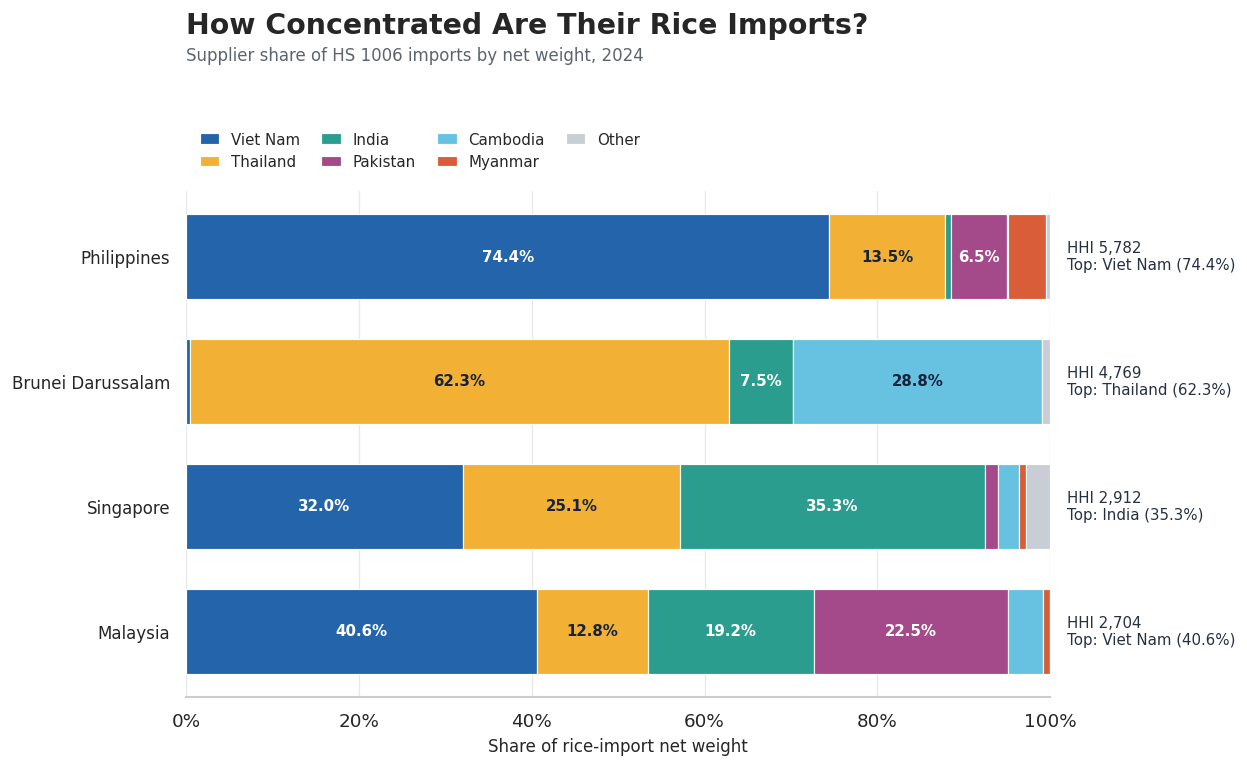

PNG tersimpan di: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\02_visualizations\final\rice_import_supplier_concentration_2024.png
SVG tersimpan di: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\02_visualizations\final\rice_import_supplier_concentration_2024.svg


In [31]:
colors = {
    "Viet Nam": "#2364AA",
    "Thailand": "#F2B134",
    "India": "#2A9D8F",
    "Pakistan": "#A44A8B",
    "Cambodia": "#66C2E0",
    "Myanmar": "#D95D39",
    "Other": "#C9CED6",
}
fallback_colors = plt.cm.tab20(np.linspace(0, 1, max(len(extra_suppliers), 1)))
for supplier, color in zip(extra_suppliers, fallback_colors):
    colors[supplier] = color

dark_text_suppliers = {"Thailand", "Cambodia", "Other"}

fig, ax = plt.subplots(figsize=(12, 6.8))
y = np.arange(len(plot_data))
left = np.zeros(len(plot_data))

for supplier in supplier_order:
    values = plot_data[supplier].to_numpy()
    ax.barh(
        y, values, left=left, label=supplier, color=colors[supplier],
        height=0.68, edgecolor="white", linewidth=0.7
    )

    for index, value in enumerate(values):
        if value >= MIN_LABEL_PCT:
            ax.text(
                left[index] + value / 2, index, f"{value:.1f}%",
                ha="center", va="center", fontsize=9,
                color="#17233C" if supplier in dark_text_suppliers else "white",
                fontweight="bold",
            )
    left += values

hhi_indexed = hhi_summary.set_index("reporterDesc")
for index, country in enumerate(plot_data.index):
    hhi_value = hhi_indexed.loc[country, "HHI_10000"]
    top_name = hhi_indexed.loc[country, "top_supplier"]
    top_share = hhi_indexed.loc[country, "top_supplier_share_pct"]
    ax.text(
        1.02, index,
        f"HHI {hhi_value:,.0f}\nTop: {top_name} ({top_share:.1f}%)",
        transform=ax.get_yaxis_transform(), ha="left", va="center",
        fontsize=9, color="#273043",
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_data.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlabel("Share of rice-import net weight", fontsize=10)
ax.set_ylabel("")

fig.suptitle(
    "How Concentrated Are Their Rice Imports?",
    x=0.16, y=0.97, ha="left", fontsize=17, fontweight="bold"
)
fig.text(
    0.16, 0.91, "Supplier share of HS 1006 imports by net weight, 2024",
    ha="left", fontsize=10, color="#5D6470"
)

ax.legend(
    ncol=4, frameon=False, loc="lower left",
    bbox_to_anchor=(0, 1.015), fontsize=9, handlelength=1.3, columnspacing=1.4
)
ax.grid(axis="x", color="#E6E8EC", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

fig.subplots_adjust(right=0.76, top=0.75, left=0.16, bottom=0.13)

png_path = FIGURE_DIR / "rice_import_supplier_concentration_2024.png"
svg_path = FIGURE_DIR / "rice_import_supplier_concentration_2024.svg"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")
plt.show()

print("PNG tersimpan di:", png_path.resolve())
print("SVG tersimpan di:", svg_path.resolve())

## 12. Mengekspor tabel hasil

Tabel lengkap tetap menyimpan seluruh pemasok asli. Tabel khusus visual berisi kategori yang sudah disederhanakan dengan `Other`.

In [32]:
supplier_share_path = OUTPUT_DIR / "supplier_share_all_partners_2024.csv"
hhi_path = OUTPUT_DIR / "hhi_summary_2024.csv"
quality_path = OUTPUT_DIR / "quality_check_2024.csv"
plot_table_path = OUTPUT_DIR / "stacked_bar_share_table_2024.csv"

supplier_share_table.to_csv(supplier_share_path, index=False)
hhi_summary.to_csv(hhi_path, index=False)
quality_check.to_csv(quality_path, index=False)
plot_data.reset_index().to_csv(plot_table_path, index=False)

print("File hasil:")
for path in [supplier_share_path, hhi_path, quality_path, plot_table_path]:
    print("-", path.resolve())

File hasil:
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\supplier_concentration\supplier_share_all_partners_2024.csv
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\supplier_concentration\hhi_summary_2024.csv
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\supplier_concentration\quality_check_2024.csv
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\supplier_concentration\stacked_bar_share_table_2024.csv


## 13. Ringkasan pembacaan hasil

Berdasarkan data ini, Filipina memiliki konsentrasi pemasok tertinggi. Sekitar 74,4% volume impor berasnya berasal dari Viet Nam. Brunei Darussalam juga terkonsentrasi, terutama pada Thailand dan Cambodia. Singapura dan Malaysia memiliki pembagian pemasok yang lebih beragam dibanding dua negara tersebut, tetapi HHI keduanya masih berada di atas 1.800.

HHI hanya menggambarkan konsentrasi pemasok. Indikator ini belum memasukkan stok domestik, kebijakan ekspor, kontrak dagang, jalur logistik, kualitas beras, atau kemampuan berpindah pemasok.

# 3. El Nino dan sensitivitas hasil padi

# Heatmap Respons Yield Padi Selama Episode El Niño Historis

Notebook ini menjawab satu pertanyaan: **ketika El Niño terjadi pada masa lalu, seberapa jauh yield padi setiap negara ASEAN bergerak dari tren jangka panjangnya?**

Metode utama:

1. Membersihkan data RONI dan yield padi.
2. Mendeteksi episode El Niño dari RONI ≥ +0,5°C selama sedikitnya lima musim tiga bulanan berturut-turut.
3. Mengestimasi expected yield dengan tren kuadratik per negara pada 1990 sampai tahun lengkap terbaru.
4. Menghitung yield anomaly dalam persen.
5. Merata-ratakan anomaly pada seluruh tahun berlabel NOAA yang dilewati episode.
6. Membuat heatmap dengan skala warna simetris terhadap nol.
7. Memeriksa sensitivitas terhadap tren linear, peak year, dan tahun setelah peak.

**Input:** `RONI_3_Months.csv` dan `rice-yields(1).csv`  
**Negara:** Cambodia, Indonesia, Lao PDR, Malaysia, Myanmar, Philippines, Thailand, dan Viet Nam.

Sumber konsep dan definisi: [NOAA CPC RONI](https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/) dan [FAOSTAT Crops and Livestock Products](https://www.fao.org/faostat/).


In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", font_scale=0.95)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

SEASONS = [
    "DJF", "JFM", "FMA", "MAM", "AMJ", "MJJ",
    "JJA", "JAS", "ASO", "SON", "OND", "NDJ"
]
SEASON_ORDER = {season: order for order, season in enumerate(SEASONS)}

TARGET_COUNTRIES = [
    "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
    "Myanmar", "Philippines", "Thailand", "Viet Nam"
]
COUNTRY_NAME_MAP = {"Laos": "Lao PDR", "Vietnam": "Viet Nam"}

ANALYSIS_START = 1990
RONI_THRESHOLD = 0.5
MIN_CONSECUTIVE_SEASONS = 5


def find_project_root():
    """Temukan akar proyek dari folder kerja notebook saat ini."""
    start = Path.cwd().resolve()
    for folder in (start, *start.parents):
        if (folder / "00_data").exists() and (folder / "01_notebooks").exists():
            return folder
    raise FileNotFoundError("Folder akar proyek RASIO tidak ditemukan.")


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "00_data" / "raw"

def find_project_root():
    """Temukan akar proyek dari folder kerja notebook saat ini."""
    start = Path.cwd().resolve()
    for folder in (start, *start.parents):
        if (folder / "00_data").exists() and (folder / "01_notebooks").exists():
            return folder
    raise FileNotFoundError("Folder akar proyek RASIO tidak ditemukan.")


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "00_data" / "raw"

def resolve_input(filename):
    candidate = RAW_DATA_DIR / filename
    if candidate.exists():
        return candidate.resolve()
    raise FileNotFoundError(f"{filename} tidak ditemukan di {RAW_DATA_DIR}")

RONI_PATH = resolve_input("RONI_3_Months.csv")
YIELD_PATH = resolve_input("rice-yields.csv")

print("RONI source :", RONI_PATH)
print("Yield source:", YIELD_PATH)


RONI source : C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\raw\RONI_3_Months.csv
Yield source: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\raw\rice-yields.csv


## 1. Memuat dan memeriksa data sumber

Pemeriksaan awal memastikan nama kolom, unit yield, jumlah baris, dan bentuk tabel RONI sesuai dengan yang dibutuhkan. File sumber tidak diubah.


In [34]:
roni_raw = pd.read_csv(RONI_PATH, dtype=str)
yield_raw = pd.read_csv(YIELD_PATH)

print(f"RONI raw: {roni_raw.shape[0]} baris × {roni_raw.shape[1]} kolom")
print(f"Yield raw: {yield_raw.shape[0]} baris × {yield_raw.shape[1]} kolom")
print("\nKolom RONI:", list(roni_raw.columns))
print("Kolom yield:", list(yield_raw.columns))

display(roni_raw.head(5))
display(yield_raw.head(5))

required_roni = {"Year", *SEASONS}
required_yield = {"Entity", "Year", "Rice - Yield (tonnes per hectare)"}
assert required_roni.issubset(roni_raw.columns), "Kolom RONI tidak lengkap"
assert required_yield.issubset(yield_raw.columns), "Kolom yield tidak lengkap"


RONI raw: 84 baris × 13 kolom
Yield raw: 640 baris × 4 kolom

Kolom RONI: ['Year', 'DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO', 'SON', 'OND', 'NDJ']
Kolom yield: ['Entity', 'Code', 'Year', 'Rice - Yield (tonnes per hectare)']


,Year,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
0,1950,-1.2,-1.1,-1.0,-1.0,-1.0,-0.7,-0.4,-0.3,-0.3,-0.4,-0.4,-0.5
1,1951,-0.3,0.1,0.5,0.6,0.6,0.7,0.8,1.0,1.0,1.0,0.9,0.7
2,1952,0.7,0.3,0.5,0.2,0.0,-0.4,-0.4,-0.1,0.1,0.0,-0.1,0.1
3,1953,0.4,0.7,0.7,0.7,0.9,0.8,0.7,0.7,0.7,0.8,0.6,0.7
4,1954,0.6,0.6,0.3,0.0,-0.2,-0.2,-0.4,-0.6,-0.5,-0.3,-0.1,-0.2


,Entity,Code,Year,Rice - Yield (tonnes per hectare)
0,Brunei,BRN,1961,1.7306
1,Brunei,BRN,1962,1.8527
2,Brunei,BRN,1963,1.3711
3,Brunei,BRN,1964,1.3235
4,Brunei,BRN,1965,1.1737


## 2. Membersihkan dan membatasi periode analisis

- Baris header berulang di dalam CSV RONI dibuang dengan mengubah `Year` menjadi numerik.
- Nilai RONI yang belum tersedia dibuang setelah tabel diubah ke format panjang.
- Nama `Laos` dan `Vietnam` diselaraskan menjadi `Lao PDR` dan `Viet Nam`.
- Brunei dan East Timor tidak masuk heatmap.
- Tahun akhir dipilih sebagai tahun terbaru yang memiliki data yield untuk semua delapan negara.

**Catatan kualitas data:** file yield yang diberikan tidak memiliki kolom `Flag`. Karena itu, notebook ini tidak dapat membedakan data resmi, estimasi FAO, dan hasil imputasi.


In [35]:
# RONI: buang header berulang dan ubah menjadi tabel Year, Season, RONI.
roni_numeric_year = pd.to_numeric(roni_raw["Year"], errors="coerce")
repeated_header_rows = int(roni_numeric_year.isna().sum())

roni_wide = roni_raw.loc[roni_numeric_year.notna(), ["Year", *SEASONS]].copy()
roni_wide["Year"] = pd.to_numeric(roni_wide["Year"]).astype(int)

roni_long = roni_wide.melt(
    id_vars="Year",
    value_vars=SEASONS,
    var_name="Season",
    value_name="RONI"
)
roni_long["RONI"] = pd.to_numeric(roni_long["RONI"], errors="coerce")
missing_roni_values = int(roni_long["RONI"].isna().sum())
roni_long["Season_Order"] = roni_long["Season"].map(SEASON_ORDER)
roni_long = (
    roni_long.dropna(subset=["RONI"])
    .sort_values(["Year", "Season_Order"])
    .reset_index(drop=True)
)

# Yield: samakan nama kolom, negara, unit, dan tipe data.
yield_data = yield_raw.rename(
    columns={
        "Entity": "Country",
        "Rice - Yield (tonnes per hectare)": "Yield"
    }
).copy()
yield_data["Country"] = yield_data["Country"].replace(COUNTRY_NAME_MAP)
yield_data["Year"] = pd.to_numeric(yield_data["Year"], errors="coerce")
yield_data["Yield"] = pd.to_numeric(yield_data["Yield"], errors="coerce")
yield_data = yield_data[yield_data["Country"].isin(TARGET_COUNTRIES)].copy()

# Tahun lengkap berarti semua delapan negara memiliki satu nilai yield nonmissing.
complete_year_counts = (
    yield_data.dropna(subset=["Year", "Yield"])
    .groupby("Year")["Country"]
    .nunique()
)
complete_years = complete_year_counts[complete_year_counts.eq(len(TARGET_COUNTRIES))].index.astype(int)
analysis_end = int(max(year for year in complete_years if year >= ANALYSIS_START))

yield_data = yield_data[
    yield_data["Year"].between(ANALYSIS_START, analysis_end)
].copy()
yield_data["Year"] = yield_data["Year"].astype(int)
yield_data = yield_data.sort_values(["Country", "Year"]).reset_index(drop=True)

duplicate_country_years = int(yield_data.duplicated(["Country", "Year"]).sum())
country_qc = (
    yield_data.groupby("Country")
    .agg(
        First_Year=("Year", "min"),
        Last_Year=("Year", "max"),
        Observations=("Year", "size"),
        Missing_Yield=("Yield", lambda s: int(s.isna().sum())),
        Min_Yield_t_ha=("Yield", "min"),
        Max_Yield_t_ha=("Yield", "max"),
    )
    .reindex(TARGET_COUNTRIES)
)

print(f"Header berulang yang dibuang dari RONI: {repeated_header_rows}")
print(f"Nilai RONI kosong yang dibuang: {missing_roni_values}")
print(f"Periode yield bersama: {ANALYSIS_START}–{analysis_end}")
print(f"Duplikat country-year: {duplicate_country_years}")
print("Flag tersedia:", "Flag" in yield_raw.columns)
display(country_qc.round(3))

assert duplicate_country_years == 0
assert country_qc["Missing_Yield"].sum() == 0
assert country_qc["Observations"].nunique() == 1


Header berulang yang dibuang dari RONI: 7
Nilai RONI kosong yang dibuang: 6
Periode yield bersama: 1990–2024
Duplikat country-year: 0
Flag tersedia: False


,First_Year,Last_Year,Observations,Missing_Yield,Min_Yield_t_ha,Max_Yield_t_ha
Country,,,,,,
Cambodia,1990,2024,35,0,1.3070,3.6440
Indonesia,1990,2024,35,0,4.1970,5.3590
Lao PDR,1990,2024,35,0,2.1980,4.2630
Malaysia,1990,2024,35,0,2.7690,4.6290
Myanmar,1990,2024,35,0,2.8860,4.0660
Philippines,1990,2024,35,0,2.6990,4.1650
Thailand,1990,2024,35,0,1.9560,3.2140
Viet Nam,1990,2024,35,0,3.1130,6.1520


## 3. Mendeteksi episode El Niño dari RONI

Setiap musim dengan RONI ≥ +0,5°C ditandai sebagai musim hangat. Musim hangat yang berurutan dikelompokkan menjadi satu run. Hanya run dengan sedikitnya lima musim yang dipertahankan sebagai episode El Niño.

`Event_Years` menggunakan label tahun pada tabel NOAA. Ini konsisten dengan struktur contoh, sehingga episode DJF–SON 1993 tetap diperlakukan sebagai episode satu tahun `1993`.


In [36]:
roni_long["Warm_Season"] = roni_long["RONI"].ge(RONI_THRESHOLD)
roni_long["Run_ID"] = roni_long["Warm_Season"].ne(
    roni_long["Warm_Season"].shift(fill_value=False)
).cumsum()

detected_rows = []
for _, run in roni_long.loc[roni_long["Warm_Season"]].groupby("Run_ID", sort=False):
    if len(run) < MIN_CONSECUTIVE_SEASONS:
        continue
    start = run.iloc[0]
    end = run.iloc[-1]
    peak = run.loc[run["RONI"].idxmax()]
    start_year = int(start["Year"])
    end_year = int(end["Year"])
    detected_rows.append(
        {
            "Start_Season": f"{start['Season']} {start_year}",
            "End_Season": f"{end['Season']} {end_year}",
            "Peak_Season": f"{peak['Season']} {int(peak['Year'])}",
            "Start_Year": start_year,
            "End_Year": end_year,
            "Peak_Year": int(peak["Year"]),
            "Peak_RONI": float(peak["RONI"]),
            "Warm_Seasons": int(len(run)),
            "Event_Years": tuple(range(start_year, end_year + 1)),
        }
    )

all_episodes = pd.DataFrame(detected_rows)

available_pairs = set(zip(yield_data["Country"], yield_data["Year"]))


def has_complete_yield(event_years):
    return all(
        (country, year) in available_pairs
        for country in TARGET_COUNTRIES
        for year in event_years
    )


episodes = all_episodes[
    all_episodes["Start_Year"].ge(ANALYSIS_START)
    & all_episodes["End_Year"].le(analysis_end)
].copy()
episodes["Complete_Yield"] = episodes["Event_Years"].map(has_complete_yield)
episodes = episodes.loc[episodes["Complete_Yield"]].reset_index(drop=True)
episodes.insert(0, "Episode_ID", [f"EN_{i:02d}" for i in range(1, len(episodes) + 1)])
episodes["Episode_Label"] = episodes.apply(
    lambda row: str(row["Start_Year"])
    if row["Start_Year"] == row["End_Year"]
    else f"{row['Start_Year']}-{str(row['End_Year'])[-2:]}",
    axis=1,
)

episode_table = episodes[
    [
        "Episode_ID", "Episode_Label", "Start_Season", "End_Season",
        "Peak_Season", "Peak_RONI", "Warm_Seasons", "Event_Years"
    ]
]

print(f"Episode terdeteksi pada seluruh periode RONI: {len(all_episodes)}")
print(f"Episode yang masuk heatmap {ANALYSIS_START}–{analysis_end}: {len(episodes)}")
display(episode_table)

assert episodes["Complete_Yield"].all()
assert episodes["Episode_Label"].is_unique


Episode terdeteksi pada seluruh periode RONI: 25
Episode yang masuk heatmap 1990–2024: 11


,Episode_ID,Episode_Label,Start_Season,End_Season,Peak_Season,Peak_RONI,Warm_Seasons,Event_Years
0,EN_01,1991-92,AMJ 1991,JJA 1992,DJF 1992,2.1000,15,"(1991, 1992)"
1,EN_02,1993,DJF 1993,SON 1993,MAM 1993,1.1000,10,"(1993,)"
2,EN_03,1994-95,JJA 1994,FMA 1995,NDJ 1994,1.3000,9,"(1994, 1995)"
3,EN_04,1997-98,MAM 1997,MAM 1998,OND 1997,2.3000,13,"(1997, 1998)"
4,EN_05,2002-03,JJA 2002,JFM 2003,OND 2002,1.3000,8,"(2002, 2003)"
5,EN_06,2004-05,JJA 2004,DJF 2005,JAS 2004,0.7000,7,"(2004, 2005)"
6,EN_07,2006-07,ASO 2006,DJF 2007,OND 2006,0.9000,5,"(2006, 2007)"
7,EN_08,2009-10,ASO 2009,FMA 2010,NDJ 2009,1.5000,7,"(2009, 2010)"
8,EN_09,2014-16,OND 2014,MAM 2016,NDJ 2015,2.3000,18,"(2014, 2015, 2016)"
9,EN_10,2018-19,SON 2018,MAM 2019,OND 2018,0.8000,7,"(2018, 2019)"


## 4. Mengestimasi expected yield

Tren dihitung terpisah untuk setiap negara agar perubahan teknologi, varietas, pupuk, dan irigasi tidak keliru dibaca sebagai dampak El Niño.

Metode utama adalah tren kuadratik:

\[
\widehat{Yield}_{i,t}=\beta_{0,i}+\beta_{1,i}x_t+\beta_{2,i}x_t^2
\]

dengan \(x_t = Year_t - \overline{Year}\). Tahun dipusatkan untuk menjaga stabilitas numerik. Tren linear dihitung pada data yang sama sebagai sensitivity check.


In [37]:
def fit_yield_trends(group):
    group = group.sort_values("Year").copy()
    x = group["Year"].to_numpy(dtype=float)
    y = group["Yield"].to_numpy(dtype=float)
    x_centered = x - x.mean()

    coef_quad = np.polyfit(x_centered, y, deg=2)
    coef_linear = np.polyfit(x_centered, y, deg=1)

    expected_quad = np.polyval(coef_quad, x_centered)
    expected_linear = np.polyval(coef_linear, x_centered)

    group["Expected_Yield_Quadratic"] = expected_quad
    group["Expected_Yield_Linear"] = expected_linear
    group["Yield_Anomaly_Quadratic"] = (y / expected_quad - 1) * 100
    group["Yield_Anomaly_Linear"] = (y / expected_linear - 1) * 100
    return group


yield_parts = [
    fit_yield_trends(group)
    for _, group in yield_data.groupby("Country", sort=False)
]
yield_anomalies = pd.concat(yield_parts, ignore_index=True)


def r_squared(actual, fitted):
    actual = np.asarray(actual)
    fitted = np.asarray(fitted)
    ss_res = np.square(actual - fitted).sum()
    ss_tot = np.square(actual - actual.mean()).sum()
    return 1 - ss_res / ss_tot


trend_qc_rows = []
for country, group in yield_anomalies.groupby("Country"):
    trend_qc_rows.append(
        {
            "Country": country,
            "R2_Quadratic": r_squared(group["Yield"], group["Expected_Yield_Quadratic"]),
            "R2_Linear": r_squared(group["Yield"], group["Expected_Yield_Linear"]),
            "Min_Expected_Quadratic": group["Expected_Yield_Quadratic"].min(),
            "Min_Expected_Linear": group["Expected_Yield_Linear"].min(),
        }
    )

trend_qc = pd.DataFrame(trend_qc_rows).set_index("Country").reindex(TARGET_COUNTRIES)
display(trend_qc.round(3))

assert (trend_qc[["Min_Expected_Quadratic", "Min_Expected_Linear"]] > 0).all().all()


,R2_Quadratic,R2_Linear,Min_Expected_Quadratic,Min_Expected_Linear
Country,,,,
Cambodia,0.9740,0.9710,1.1950,1.2820
Indonesia,0.8820,0.8810,4.1890,4.1690
Lao PDR,0.9400,0.8800,2.0790,2.4030
Malaysia,0.6930,0.6000,2.6800,2.9280
Myanmar,0.9100,0.7880,2.7390,3.0180
Philippines,0.9230,0.9180,2.6590,2.7310
Thailand,0.9170,0.6780,1.9710,2.3060
Viet Nam,0.9900,0.9650,3.0070,3.3140


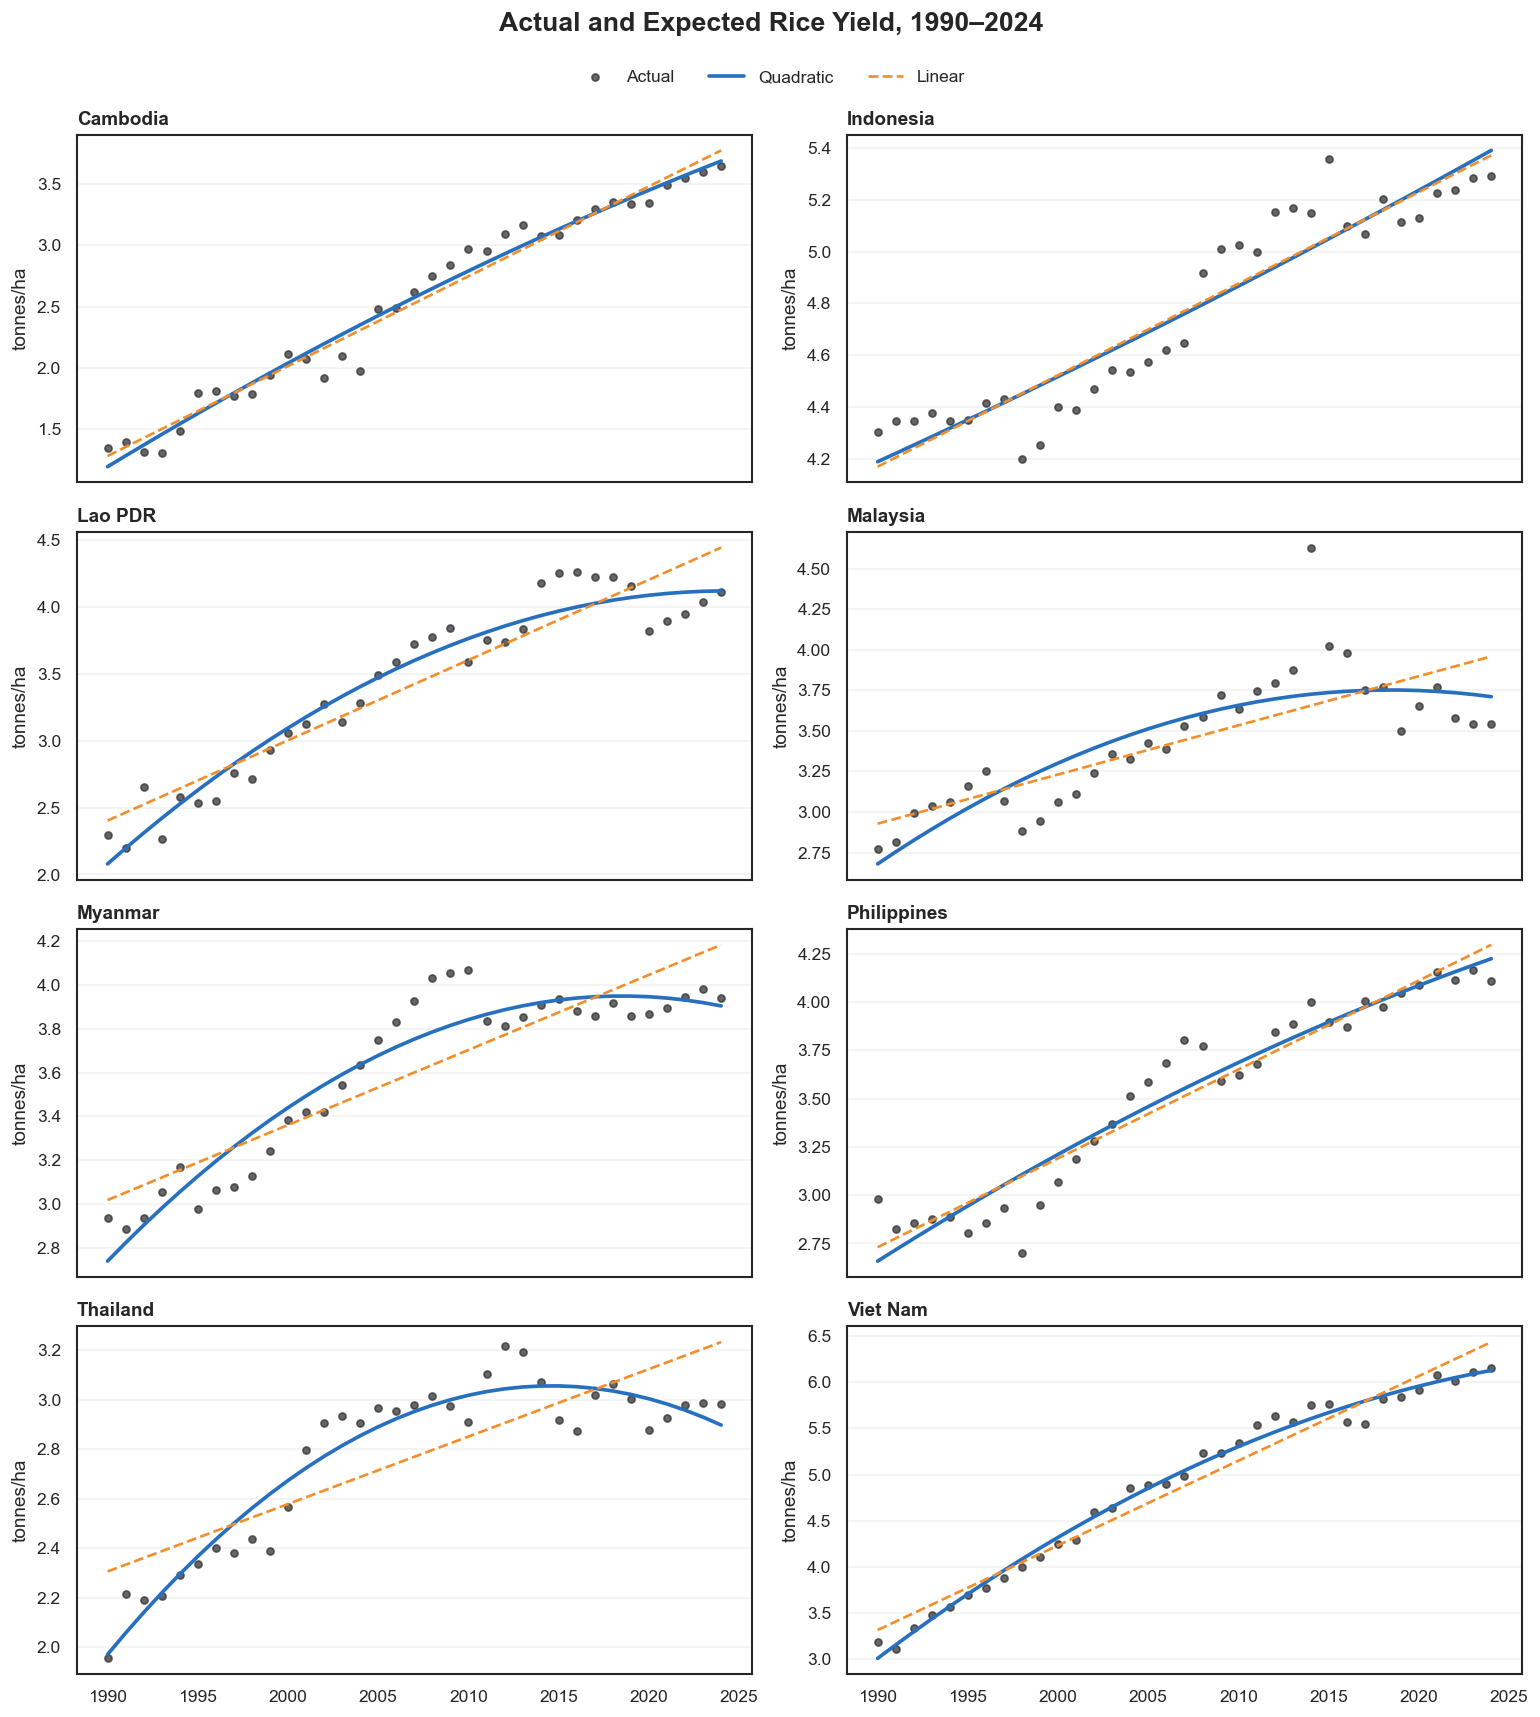

In [38]:
fig, axes = plt.subplots(4, 2, figsize=(13, 14), sharex=True)
for ax, country in zip(axes.flat, TARGET_COUNTRIES):
    group = yield_anomalies[yield_anomalies["Country"].eq(country)]
    ax.scatter(group["Year"], group["Yield"], s=18, color="#333333", alpha=0.75, label="Actual")
    ax.plot(group["Year"], group["Expected_Yield_Quadratic"], color="#276FBF", lw=2.2, label="Quadratic")
    ax.plot(group["Year"], group["Expected_Yield_Linear"], color="#F28E2B", lw=1.6, ls="--", label="Linear")
    ax.set_title(country, loc="left", fontweight="bold")
    ax.set_ylabel("tonnes/ha")
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.995))
fig.suptitle(
    f"Actual and Expected Rice Yield, {ANALYSIS_START}–{analysis_end}",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
fig.tight_layout()
plt.show()


## 5. Menghitung yield anomaly

Untuk setiap negara dan tahun:

\[
YieldAnomaly_{i,t}=\left(\frac{ActualYield_{i,t}}{ExpectedYield_{i,t}}-1\right)\times100
\]

Nilai negatif berarti yield berada di bawah tren yang diharapkan. Nilai positif berarti yield berada di atas tren. Nilai ini bukan perubahan dari tahun sebelumnya.


In [39]:
anomaly_preview = yield_anomalies[
    [
        "Country", "Year", "Yield", "Expected_Yield_Quadratic",
        "Yield_Anomaly_Quadratic", "Expected_Yield_Linear",
        "Yield_Anomaly_Linear"
    ]
].copy()

display(anomaly_preview.groupby("Country", sort=False).head(2).round(3))

anomaly_summary = (
    yield_anomalies.groupby("Country")
    .agg(
        Mean_Anomaly=("Yield_Anomaly_Quadratic", "mean"),
        Min_Anomaly=("Yield_Anomaly_Quadratic", "min"),
        Max_Anomaly=("Yield_Anomaly_Quadratic", "max"),
    )
    .reindex(TARGET_COUNTRIES)
)
display(anomaly_summary.round(2))


,Country,Year,Yield,Expected_Yield_Quadratic,Yield_Anomaly_Quadratic,Expected_Yield_Linear,Yield_Anomaly_Linear
0,Cambodia,1990,1.3480,1.1950,12.7600,1.2820,5.1270
1,Cambodia,1991,1.3960,1.2840,8.7550,1.3550,3.0200
35,Indonesia,1990,4.3020,4.1890,2.7050,4.1690,3.1780
36,Indonesia,1991,4.3470,4.2200,2.9860,4.2050,3.3740
70,Lao PDR,1990,2.2940,2.0790,10.3090,2.4030,-4.5470
71,Lao PDR,1991,2.1980,2.1960,0.0650,2.4630,-10.7630
105,Malaysia,1990,2.7690,2.6800,3.3340,2.9280,-5.4160
106,Malaysia,1991,2.8180,2.7540,2.3120,2.9580,-4.7490
140,Myanmar,1990,2.9350,2.7390,7.1510,3.0180,-2.7440
141,Myanmar,1991,2.8860,2.8230,2.2270,3.0520,-5.4610


,Mean_Anomaly,Min_Anomaly,Max_Anomaly
Country,,,
Cambodia,0.0900,-15.9000,12.7600
Indonesia,0.0000,-5.6800,6.1300
Lao PDR,0.0600,-7.1100,14.9600
Malaysia,0.0200,-9.8600,24.2500
Myanmar,0.0100,-5.8700,7.1500
Philippines,0.0100,-13.1400,12.0300
Thailand,0.0100,-8.7900,7.7500
Viet Nam,0.0200,-4.2900,5.7900


## 6. Menghubungkan anomaly dengan episode El Niño

Untuk metode utama, anomaly tahunan dirata-ratakan pada seluruh `Event_Years`:

\[
EventAnomaly_{i,e}=\frac{1}{n_e}\sum_{t\in e}YieldAnomaly_{i,t}
\]

Notebook juga mengambil anomaly pada `Peak_Year` dan `Peak_Year + 1`. Keduanya dipakai sebagai pemeriksaan timing, bukan sebagai pengganti metode utama.


In [40]:
event_rows = []
for _, episode in episodes.iterrows():
    event_years = list(episode["Event_Years"])
    peak_year = int(episode["Peak_Year"])
    t_plus_1 = peak_year + 1

    for country in TARGET_COUNTRIES:
        country_data = yield_anomalies[yield_anomalies["Country"].eq(country)]
        window = country_data[country_data["Year"].isin(event_years)]
        peak = country_data[country_data["Year"].eq(peak_year)]
        lagged = country_data[country_data["Year"].eq(t_plus_1)]

        event_rows.append(
            {
                "Episode_ID": episode["Episode_ID"],
                "Episode_Label": episode["Episode_Label"],
                "Country": country,
                "Event_Years": episode["Event_Years"],
                "Peak_Year": peak_year,
                "T_plus_1_Year": t_plus_1,
                "Years_Averaged": int(len(window)),
                "Event_Anomaly_Quadratic": window["Yield_Anomaly_Quadratic"].mean(),
                "Event_Anomaly_Linear": window["Yield_Anomaly_Linear"].mean(),
                "Peak_Year_Anomaly": peak["Yield_Anomaly_Quadratic"].iloc[0] if len(peak) else np.nan,
                "T_plus_1_Anomaly": lagged["Yield_Anomaly_Quadratic"].iloc[0] if len(lagged) else np.nan,
            }
        )

event_data = pd.DataFrame(event_rows)
episode_order = episodes["Episode_Label"].tolist()

heatmap_data = (
    event_data.pivot(
        index="Country",
        columns="Episode_Label",
        values="Event_Anomaly_Quadratic"
    )
    .reindex(index=TARGET_COUNTRIES, columns=episode_order)
)

display(heatmap_data.round(1))

assert event_data["Years_Averaged"].ge(1).all()
assert heatmap_data.notna().all().all()


Episode_Label,1991-92,1993,1994-95,1997-98,2002-03,2004-05,2006-07,2009-10,2014-16,2018-19,2023-24
Country,,,,,,,,,,,
Cambodia,2.4000,-10.4000,3.2000,-3.1000,-10.2000,-6.9000,0.7000,5.3000,-0.2000,-0.4000,-1.0000
Indonesia,2.6000,2.1000,0.3000,-2.7000,-2.1000,-2.5000,-2.3000,3.5000,3.0000,-0.4000,-1.6000
Lao PDR,7.5000,-6.3000,-0.8000,-4.7000,-2.6000,-1.5000,2.4000,-0.6000,6.6000,3.2000,-1.1000
Malaysia,4.1000,4.9000,4.0000,-6.1000,-3.4000,-3.4000,-2.9000,0.9000,12.7000,-3.1000,-4.7000
Myanmar,1.6000,2.5000,-0.6000,-5.7000,-2.4000,1.0000,3.8000,6.1000,-0.6000,-1.5000,1.3000
Philippines,3.4000,1.5000,-2.4000,-8.5000,-0.4000,3.4000,6.0000,-1.6000,0.7000,-0.6000,-1.7000
Thailand,5.1000,-0.5000,-0.7000,-4.8000,4.6000,2.2000,1.0000,-2.2000,-3.2000,0.1000,2.4000
Viet Nam,-0.1000,1.3000,-0.3000,-2.1000,0.4000,1.5000,-1.1000,0.5000,0.5000,-0.9000,0.4000


## 7. Heatmap utama

Merah menunjukkan yield di bawah tren, krem mendekati tren, biru menunjukkan yield di atas tren, dan abu-abu disiapkan untuk data yang tidak tersedia. Batas warna menggunakan persentil ke-95 dari nilai absolut lalu diterapkan secara simetris terhadap nol.


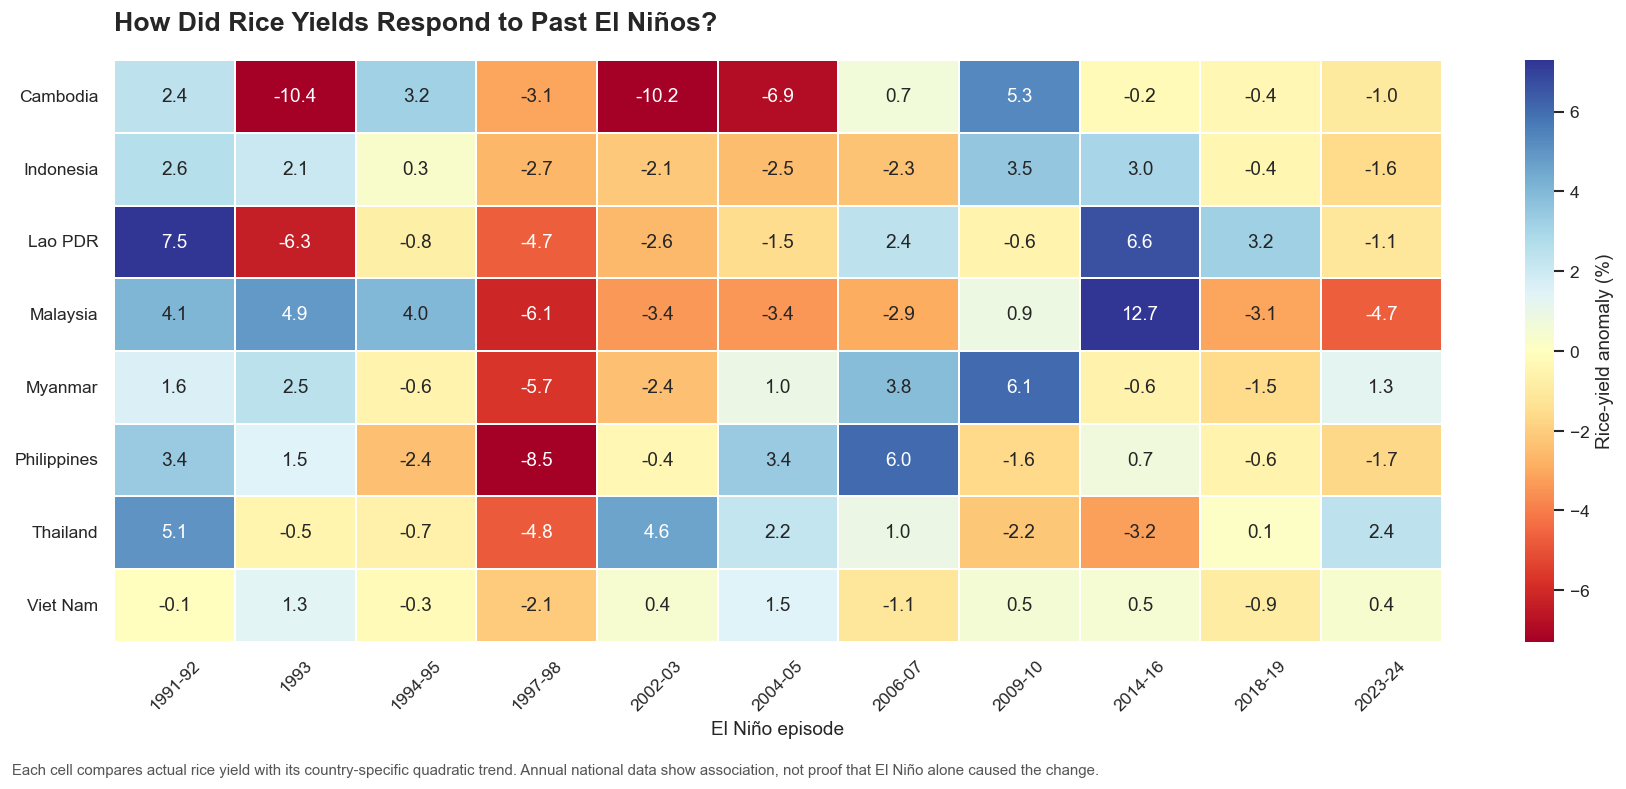

Batas warna simetris: -7.29% sampai +7.29%


In [41]:
values = heatmap_data.to_numpy(dtype=float)
color_limit = float(np.nanpercentile(np.abs(values), 95))

cmap = mpl.colormaps["RdYlBu"].copy()
cmap.set_bad("#D9D9D9")

fig, ax = plt.subplots(figsize=(15, 6.4))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap=cmap,
    center=0,
    vmin=-color_limit,
    vmax=color_limit,
    annot=True,
    fmt=".1f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Rice-yield anomaly (%)"},
)

ax.set_title(
    "How Did Rice Yields Respond to Past El Niños?",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18,
)
ax.set_xlabel("El Niño episode")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
fig.text(
    0.01,
    -0.02,
    "Each cell compares actual rice yield with its country-specific quadratic trend. "
    "Annual national data show association, not proof that El Niño alone caused the change.",
    fontsize=9,
    color="#555555",
)
fig.tight_layout()
plt.show()

print(f"Batas warna simetris: {-color_limit:.2f}% sampai +{color_limit:.2f}%")


## 8. Sensitivity check: kuadratik versus linear

Perbandingan ini memeriksa apakah kesimpulan visual terlalu bergantung pada bentuk tren. `Sign_Flips` menghitung berapa episode yang berubah dari negatif ke positif atau sebaliknya ketika tren kuadratik diganti dengan tren linear.


In [42]:
event_data["Quadratic_vs_Linear_Difference"] = (
    event_data["Event_Anomaly_Quadratic"] - event_data["Event_Anomaly_Linear"]
)
event_data["Quadratic_vs_Linear_Sign_Flip"] = (
    np.sign(event_data["Event_Anomaly_Quadratic"])
    != np.sign(event_data["Event_Anomaly_Linear"])
)

trend_sensitivity = (
    event_data.groupby("Country")
    .agg(
        Mean_Absolute_Difference=("Quadratic_vs_Linear_Difference", lambda s: s.abs().mean()),
        Max_Absolute_Difference=("Quadratic_vs_Linear_Difference", lambda s: s.abs().max()),
        Sign_Flips=("Quadratic_vs_Linear_Sign_Flip", "sum"),
        Episodes=("Episode_Label", "nunique"),
    )
    .reindex(TARGET_COUNTRIES)
)
trend_sensitivity["Sign_Flip_Rate"] = (
    trend_sensitivity["Sign_Flips"] / trend_sensitivity["Episodes"]
)

overall_flip_rate = event_data["Quadratic_vs_Linear_Sign_Flip"].mean()
overall_mean_abs_difference = event_data["Quadratic_vs_Linear_Difference"].abs().mean()
stability_label = "cukup stabil" if overall_flip_rate < 0.10 else "belum sepenuhnya stabil"

display(trend_sensitivity.round(3))
print(f"Overall sign-flip rate: {overall_flip_rate:.1%}")
print(f"Overall mean absolute difference: {overall_mean_abs_difference:.2f} percentage points")
print(f"Kesimpulan sensitivity check: pola heatmap {stability_label} terhadap pilihan tren.")


,Mean_Absolute_Difference,Max_Absolute_Difference,Sign_Flips,Episodes,Sign_Flip_Rate
Country,,,,,
Cambodia,1.7510,4.7870,2,11,0.1820
Indonesia,0.1820,0.3460,0,11,0.0000
Lao PDR,4.4800,10.2640,4,11,0.3640
Malaysia,3.2640,6.4200,3,11,0.2730
Myanmar,3.5680,6.8450,5,11,0.4550
Philippines,0.9520,1.9670,1,11,0.0910
Thailand,5.5830,11.1440,4,11,0.3640
Viet Nam,3.0080,6.5870,3,11,0.2730


Overall sign-flip rate: 25.0%
Overall mean absolute difference: 2.85 percentage points
Kesimpulan sensitivity check: pola heatmap belum sepenuhnya stabil terhadap pilihan tren.


## 9. Sensitivity check: event window, peak year, dan t+1

Jika tanda anomaly berubah antara peak year dan t+1, respons timing negara pada episode tersebut dianggap tidak konsisten. Perbandingan ini penting karena El Niño yang memuncak di akhir tahun dapat memengaruhi panen tahun berikutnya.


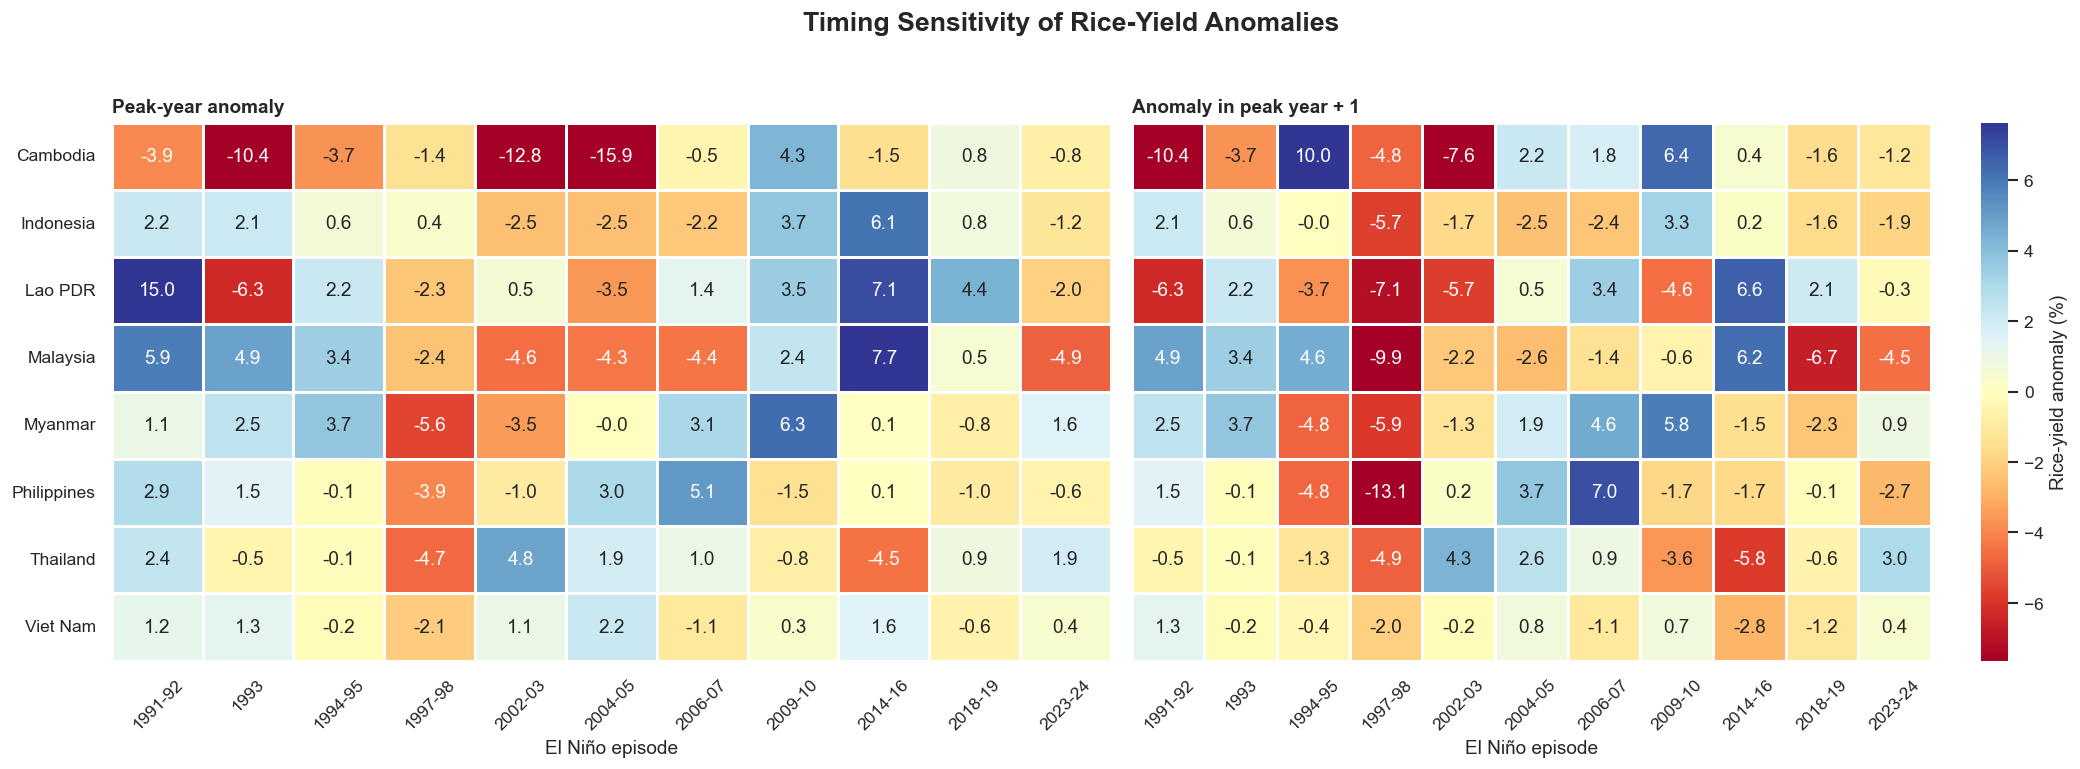

,Peak_vs_T1_Sign_Flips,Comparable_Episodes,Sign_Flip_Rate
Country,,,
Cambodia,5,11,0.4550
Indonesia,3,11,0.2730
Lao PDR,6,11,0.5450
Malaysia,2,11,0.1820
Myanmar,3,11,0.2730
Philippines,3,11,0.2730
Thailand,2,11,0.1820
Viet Nam,3,11,0.2730


In [43]:
peak_heatmap = (
    event_data.pivot(index="Country", columns="Episode_Label", values="Peak_Year_Anomaly")
    .reindex(index=TARGET_COUNTRIES, columns=episode_order)
)
t1_heatmap = (
    event_data.pivot(index="Country", columns="Episode_Label", values="T_plus_1_Anomaly")
    .reindex(index=TARGET_COUNTRIES, columns=episode_order)
)

timing_valid = event_data[["Peak_Year_Anomaly", "T_plus_1_Anomaly"]].notna().all(axis=1)
event_data["Peak_vs_T1_Sign_Flip"] = False
event_data.loc[timing_valid, "Peak_vs_T1_Sign_Flip"] = (
    np.sign(event_data.loc[timing_valid, "Peak_Year_Anomaly"])
    != np.sign(event_data.loc[timing_valid, "T_plus_1_Anomaly"])
)

timing_sensitivity = (
    event_data.loc[timing_valid]
    .groupby("Country")
    .agg(
        Peak_vs_T1_Sign_Flips=("Peak_vs_T1_Sign_Flip", "sum"),
        Comparable_Episodes=("Episode_Label", "nunique"),
    )
    .reindex(TARGET_COUNTRIES)
)
timing_sensitivity["Sign_Flip_Rate"] = (
    timing_sensitivity["Peak_vs_T1_Sign_Flips"]
    / timing_sensitivity["Comparable_Episodes"]
)

timing_limit = float(
    np.nanpercentile(
        np.abs(np.concatenate([peak_heatmap.to_numpy().ravel(), t1_heatmap.to_numpy().ravel()])),
        95,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6.2), sharey=True)
for ax, matrix, title in [
    (axes[0], peak_heatmap, "Peak-year anomaly"),
    (axes[1], t1_heatmap, "Anomaly in peak year + 1"),
]:
    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        center=0,
        vmin=-timing_limit,
        vmax=timing_limit,
        annot=True,
        fmt=".1f",
        linewidths=0.8,
        linecolor="white",
        cbar=ax is axes[1],
        cbar_kws={"label": "Rice-yield anomaly (%)"} if ax is axes[1] else None,
    )
    ax.set_title(title, fontweight="bold", loc="left")
    ax.set_xlabel("El Niño episode")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Timing Sensitivity of Rice-Yield Anomalies", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

display(timing_sensitivity.round(3))


## 10. Ringkasan hasil untuk membantu membaca heatmap

Ringkasan di bawah hanya mendeskripsikan pola historis pada data nasional. Ia tidak membuktikan bahwa El Niño merupakan satu-satunya penyebab perubahan yield.


In [44]:
country_summary = (
    event_data.groupby("Country")
    .agg(
        Mean_Event_Anomaly=("Event_Anomaly_Quadratic", "mean"),
        Below_Trend_Episodes=("Event_Anomaly_Quadratic", lambda s: int((s < 0).sum())),
        Episodes_At_or_Below_Minus_5=("Event_Anomaly_Quadratic", lambda s: int((s <= -5).sum())),
        Lowest_Anomaly=("Event_Anomaly_Quadratic", "min"),
    )
    .reindex(TARGET_COUNTRIES)
)

lowest_episode_by_country = (
    event_data.loc[event_data.groupby("Country")["Event_Anomaly_Quadratic"].idxmin(),
                   ["Country", "Episode_Label"]]
    .set_index("Country")["Episode_Label"]
)
country_summary["Lowest_Episode"] = lowest_episode_by_country

episode_summary = (
    event_data.groupby("Episode_Label", sort=False)
    .agg(
        Mean_Across_Countries=("Event_Anomaly_Quadratic", "mean"),
        Countries_Below_Trend=("Event_Anomaly_Quadratic", lambda s: int((s < 0).sum())),
        Minimum_Country_Value=("Event_Anomaly_Quadratic", "min"),
    )
    .reindex(episode_order)
)

display(country_summary.round(2))
display(episode_summary.round(2))

most_negative_episode = episode_summary["Mean_Across_Countries"].idxmin()
most_negative_mean = episode_summary.loc[most_negative_episode, "Mean_Across_Countries"]
most_negative_count = int(episode_summary.loc[most_negative_episode, "Countries_Below_Trend"])

print(
    f"Episode dengan rata-rata regional paling negatif adalah {most_negative_episode}: "
    f"{most_negative_mean:.2f}% dan {most_negative_count} dari {len(TARGET_COUNTRIES)} negara berada di bawah tren."
)
print(
    "Interpretasi aman: sel merah yang berulang menunjukkan negara yang lebih sering mencatat yield di bawah tren "
    "selama episode historis, bukan bukti bahwa RONI sendirian menyebabkan perubahan tersebut."
)


,Mean_Event_Anomaly,Below_Trend_Episodes,Episodes_At_or_Below_Minus_5,Lowest_Anomaly,Lowest_Episode
Country,,,,,
Cambodia,-1.8700,7,3,-10.3800,1993
Indonesia,-0.0100,6,0,-2.6600,1997-98
Lao PDR,0.1900,7,1,-6.3300,1993
Malaysia,0.2600,6,1,-6.1300,1997-98
Myanmar,0.5000,5,1,-5.7200,1997-98
Philippines,-0.0200,6,1,-8.5400,1997-98
Thailand,0.3600,5,0,-4.8000,1997-98
Viet Nam,0.0200,5,0,-2.0700,1997-98


,Mean_Across_Countries,Countries_Below_Trend,Minimum_Country_Value
Episode_Label,,,
1991-92,3.3300,1,-0.0500
1993,-0.6200,3,-10.3800
1994-95,0.3400,5,-2.4300
1997-98,-4.7100,8,-8.5400
2002-03,-2.0200,6,-10.2100
2004-05,-0.7900,4,-6.8700
2006-07,0.9500,3,-2.9100
2009-10,1.5000,3,-2.2100
2014-16,2.4400,3,-3.2300


Episode dengan rata-rata regional paling negatif adalah 1997-98: -4.71% dan 8 dari 8 negara berada di bawah tren.
Interpretasi aman: sel merah yang berulang menunjukkan negara yang lebih sering mencatat yield di bawah tren selama episode historis, bukan bukti bahwa RONI sendirian menyebabkan perubahan tersebut.


## Kesimpulan metode

- Heatmap memakai **yield anomaly**, bukan yield mentah.
- Expected yield utama berasal dari **tren kuadratik per negara**.
- Episode ditentukan langsung dari RONI, bukan daftar tahun manual.
- Satu episode menjadi satu kolom, dan episode lintas tahun diringkas dengan rata-rata anomaly tahunan.
- Skala warna dibuat simetris terhadap nol.
- Tren linear, peak year, dan t+1 dipakai untuk mengecek kestabilan hasil.
- Data tahunan nasional menunjukkan asosiasi historis, bukan kausalitas tunggal.


# 4. Eksposur pasokan negara defisit

# Rice Supply Exposure Bubble Chart: 2024 Trade and 2026 Production Gaps

Notebook ini membuat bubble chart untuk empat negara ASEAN yang diproyeksikan memiliki *production shortfall* beras pada 2026: Brunei Darussalam, Malaysia, Philippines, dan Singapore.

Setiap bubble menunjukkan tiga dimensi: 

- **X-axis:** supplier concentration, HHI from UN Comtrade 2024.
- **Y-axis:** projected production shortfall from AFSIS 2026.
- **Bubble area:** rice-import volume from UN Comtrade 2024.

Bubble chart ini adalah perbandingan deskriptif lintas dua tahun data. Nilainya tidak digunakan untuk memprediksi gangguan pasokan atau membentuk kategori risiko resmi.

## 1. Imports and visual settings

The visual style follows the existing supplier-concentration and clustering notebooks: clean white background, light gridlines, direct labels, and high-resolution PNG and SVG exports.

In [45]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'savefig.dpi': 300,
})

TEXT = '#273043'
MUTED = '#5D6470'
GRID = '#E6E8EC'
CORAL = '#D95D39'       # Above the four-country HHI median
TEAL = '#2A9D8F'        # At or below the four-country HHI median
REFERENCE = '#7A828E'
WHITE = '#FFFFFF'

## 2. File configuration

This notebook reuses the exported outputs from the two source notebooks instead of recalculating their full pipelines:

- `ASEAN_Rice_Clustering_Analysis_added.ipynb` exports the AFSIS 2026 master table.
- `rice_import_stacked_bar_2024.ipynb` exports the 2024 HHI summary.

Run those source notebooks first if the CSV files are not yet present.

In [46]:
MASTER_FILENAME = "asean_master_dataframe.csv"
HHI_FILENAME = "hhi_summary_2024.csv"

def find_project_root():
    """Temukan akar proyek dari folder kerja notebook saat ini."""
    start = Path.cwd().resolve()
    for folder in (start, *start.parents):
        if (folder / "00_data").exists() and (folder / "01_notebooks").exists():
            return folder
    raise FileNotFoundError("Folder akar proyek RASIO tidak ditemukan.")


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "00_data" / "raw"

MASTER_PATH = PROJECT_ROOT / "00_data" / "processed" / "clustering" / MASTER_FILENAME
HHI_PATH = PROJECT_ROOT / "00_data" / "processed" / "supplier_concentration" / HHI_FILENAME
DATA_OUTPUT_DIR = PROJECT_ROOT / "00_data" / "processed" / "supply_exposure"
FIGURE_DIR = PROJECT_ROOT / "02_visualizations" / "final"
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DEFICIT_COUNTRIES = [
    "Brunei Darussalam",
    "Malaysia",
    "Philippines",
    "Singapore",
]

print("AFSIS master table:", MASTER_PATH.resolve())
print("UN Comtrade HHI table:", HHI_PATH.resolve())
print("Data output directory:", DATA_OUTPUT_DIR.resolve())
print("Figure directory:", FIGURE_DIR.resolve())


AFSIS master table: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\clustering\asean_master_dataframe.csv
UN Comtrade HHI table: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\supplier_concentration\hhi_summary_2024.csv
Data output directory: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\supply_exposure
Figure directory: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\02_visualizations\final


## 3. Load and validate the source outputs

The AFSIS table provides the 2026 projected production shortfall. The trade table provides the 2024 supplier HHI, effective suppliers, top supplier, and import volume.

In [47]:
master = pd.read_csv(MASTER_PATH)
hhi = pd.read_csv(HHI_PATH)

required_master = {
    'Country', 'SSR_pct', 'Production_Shortfall_pct',
    'Beginning_Stock_to_Use_pct', 'Has_AFSIS_2026', 'Has_Trade_2024',
}
required_hhi = {
    'reporterDesc', 'HHI', 'HHI_10000', 'effective_suppliers',
    'import_tonnes', 'top_supplier', 'top_supplier_share_pct',
}

missing_master = required_master.difference(master.columns)
missing_hhi = required_hhi.difference(hhi.columns)
assert not missing_master, f'Missing master columns: {sorted(missing_master)}'
assert not missing_hhi, f'Missing HHI columns: {sorted(missing_hhi)}'

assert master['Country'].is_unique, 'Country must be unique in the AFSIS master table.'
assert hhi['reporterDesc'].is_unique, 'Reporter must be unique in the HHI summary table.'

print(f'AFSIS rows: {len(master):,}')
print(f'HHI rows: {len(hhi):,}')
display(master.loc[master['Country'].isin(DEFICIT_COUNTRIES), [
    'Country', 'SSR_pct', 'Production_Shortfall_pct',
    'Beginning_Stock_to_Use_pct', 'Has_AFSIS_2026', 'Has_Trade_2024',
]].sort_values('Country'))

AFSIS rows: 11
HHI rows: 4


,Country,SSR_pct,Production_Shortfall_pct,Beginning_Stock_to_Use_pct,Has_AFSIS_2026,Has_Trade_2024
0,Brunei Darussalam,9.3781,90.6219,26.5565,True,True
4,Malaysia,46.9766,53.0234,0.0000,True,True
6,Philippines,73.2137,26.7863,16.5461,True,True
7,Singapore,0.0000,100.0000,0.0000,True,True


## 4. Build the four-country bubble-chart dataset

The population is defined before visualisation: ASEAN members with a positive projected production shortfall and complete bilateral-trade coverage. This produces the four countries used in the import-exposure analysis.

In [48]:
trade_columns = [
    'reporterDesc', 'HHI', 'HHI_10000', 'effective_suppliers',
    'import_tonnes', 'top_supplier', 'top_supplier_share_pct',
]
trade = hhi[trade_columns].rename(columns={'reporterDesc': 'Country'})

bubble = (
    master.merge(trade, on='Country', how='inner', validate='one_to_one')
    .query('Production_Shortfall_pct > 0')
    .copy()
)

bubble = bubble.loc[bubble['Country'].isin(DEFICIT_COUNTRIES)].copy()
bubble = bubble.sort_values('HHI_10000').reset_index(drop=True)

assert set(bubble['Country']) == set(DEFICIT_COUNTRIES), (
    'The bubble chart must contain exactly the four deficit countries with trade data.'
)
assert len(bubble) == 4, 'Expected four countries in the bubble chart.'
assert bubble[['HHI_10000', 'effective_suppliers', 'import_tonnes', 'Production_Shortfall_pct']].notna().all().all()
assert (bubble['import_tonnes'] > 0).all()

bubble['HHI_reference_group'] = np.where(
    bubble['HHI_10000'] > bubble['HHI_10000'].median(),
    'Above four-country median',
    'At or below four-country median',
)
bubble['Bubble_colour'] = np.where(
    bubble['HHI_reference_group'].eq('Above four-country median'),
    CORAL,
    TEAL,
)

audit_columns = [
    'Country', 'SSR_pct', 'Production_Shortfall_pct',
    'Beginning_Stock_to_Use_pct', 'HHI_10000', 'effective_suppliers',
    'top_supplier', 'top_supplier_share_pct', 'import_tonnes',
]
display(bubble[audit_columns].sort_values('HHI_10000', ascending=False).round({
    'SSR_pct': 1, 'Production_Shortfall_pct': 1,
    'Beginning_Stock_to_Use_pct': 1, 'HHI_10000': 0,
    'effective_suppliers': 1, 'top_supplier_share_pct': 1,
    'import_tonnes': 0,
}))

,Country,SSR_pct,Production_Shortfall_pct,Beginning_Stock_to_Use_pct,HHI_10000,effective_suppliers,top_supplier,top_supplier_share_pct,import_tonnes
3,Philippines,73.2000,26.8000,16.5000,"5,782.0000",1.7000,Viet Nam,74.4000,"4,770,089.0000"
2,Brunei Darussalam,9.4000,90.6000,26.6000,"4,769.0000",2.1000,Thailand,62.3000,"31,286.0000"
1,Singapore,0.0000,100.0000,0.0000,"2,912.0000",3.4000,India,35.3000,"448,503.0000"
0,Malaysia,47.0000,53.0000,0.0000,"2,704.0000",3.7000,Viet Nam,40.6000,"1,695,310.0000"


## 5. Quality checks and descriptive reference lines

The expected HHI values verify that the notebook is using the same supplier-concentration calculations as `rice_import_stacked_bar_2024.ipynb`. The dashed lines in the chart are four-country medians. They are reference lines only, not official food-risk thresholds.

In [49]:
expected_hhi = {
    'Philippines': 5781.70,
    'Brunei Darussalam': 4769.07,
    'Singapore': 2912.23,
    'Malaysia': 2703.70,
}

actual_hhi = bubble.set_index('Country')['HHI_10000'].to_dict()
for country, expected in expected_hhi.items():
    assert np.isclose(actual_hhi[country], expected, atol=0.10), (
        f'Unexpected HHI for {country}: {actual_hhi[country]:.2f} vs {expected:.2f}'
    )

hhi_median = bubble['HHI_10000'].median()
shortfall_median = bubble['Production_Shortfall_pct'].median()

print('HHI quality check passed.')
print(f'Four-country median HHI: {hhi_median:,.2f}')
print(f'Four-country median production shortfall: {shortfall_median:.2f}%')
print('Coverage: 4 of 10 assessed ASEAN members have a projected production gap.')

HHI quality check passed.
Four-country median HHI: 3,840.65
Four-country median production shortfall: 71.82%
Coverage: 4 of 10 assessed ASEAN members have a projected production gap.


## 6. Create the bubble chart

Bubble area uses a square-root transformation of import volume so Brunei remains visible while the Philippines is still shown as the largest importer. Colour is paired with direct labels: coral marks countries above the four-country median HHI and blue-green marks countries at or below it.

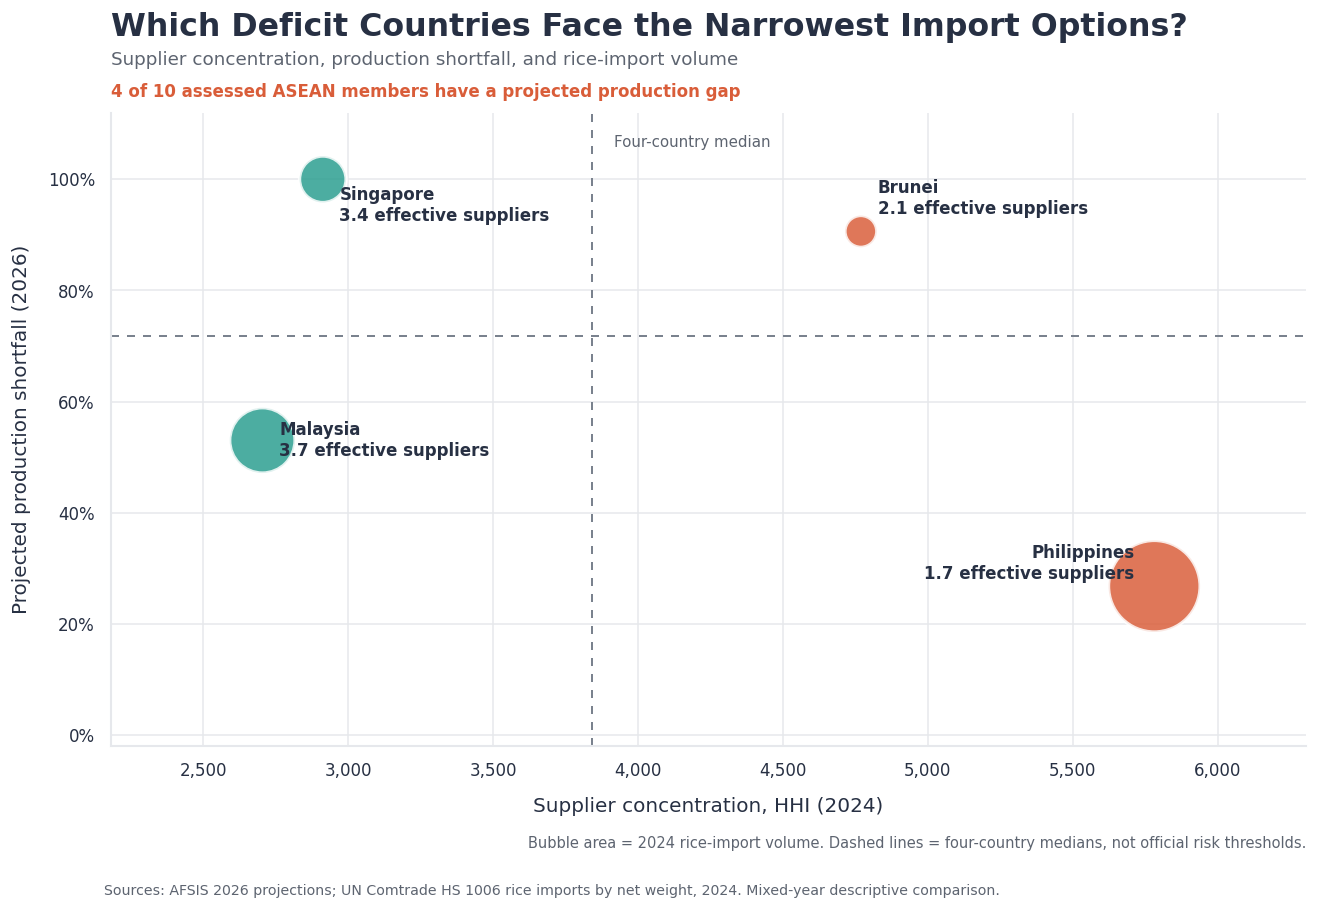

PNG saved to: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\02_visualizations\final\rice_supply_exposure_bubble_2024_2026.png
SVG saved to: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\02_visualizations\final\rice_supply_exposure_bubble_2024_2026.svg


In [50]:
def bubble_area(import_tonnes, minimum_radius=9, maximum_radius=31):
    normalized = np.sqrt(import_tonnes / import_tonnes.max())
    radius = minimum_radius + normalized * (maximum_radius - minimum_radius)
    return np.pi * radius ** 2

label_offsets = {
    'Singapore': (10, -4, 'left', 'top'),
    'Brunei Darussalam': (10, 8, 'left', 'bottom'),
    'Malaysia': (10, 0, 'left', 'center'),
    'Philippines': (-12, 2, 'right', 'bottom'),
}

short_labels = {
    'Brunei Darussalam': 'Brunei',
    'Malaysia': 'Malaysia',
    'Philippines': 'Philippines',
    'Singapore': 'Singapore',
}

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

x_span = bubble['HHI_10000'].max() - bubble['HHI_10000'].min()
ax.set_xlim(
    bubble['HHI_10000'].min() - x_span * 0.17,
    bubble['HHI_10000'].max() + x_span * 0.17,
)
ax.set_ylim(-2, 112)

ax.grid(color=GRID, linewidth=0.9)
ax.set_axisbelow(True)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)

ax.axvline(hhi_median, color=REFERENCE, linewidth=1.2, linestyle=(0, (4, 4)), zorder=1)
ax.axhline(shortfall_median, color=REFERENCE, linewidth=1.2, linestyle=(0, (4, 4)), zorder=1)
ax.text(
    hhi_median + x_span * 0.025, 108, 'Four-country median',
    fontsize=9, color=MUTED, va='top'
)

ax.scatter(
    bubble['HHI_10000'],
    bubble['Production_Shortfall_pct'],
    s=bubble_area(bubble['import_tonnes']),
    c=bubble['Bubble_colour'],
    alpha=0.84,
    edgecolors=WHITE,
    linewidths=2.0,
    zorder=3,
)

for _, row in bubble.iterrows():
    dx, dy, ha, va = label_offsets[row['Country']]
    label = f"{short_labels[row['Country']]}\n{row['effective_suppliers']:.1f} effective suppliers"
    ax.annotate(
        label,
        xy=(row['HHI_10000'], row['Production_Shortfall_pct']),
        xytext=(dx, dy),
        textcoords='offset points',
        ha=ha, va=va,
        fontsize=10, color=TEXT, fontweight='bold',
        zorder=4,
    )

ax.set_xlabel('Supplier concentration, HHI (2024)', fontsize=12, color=TEXT, labelpad=10)
ax.set_ylabel('Projected production shortfall (2026)', fontsize=12, color=TEXT, labelpad=10)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:,.0f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.0f}%'))
ax.tick_params(axis='both', colors=TEXT, labelsize=10)

ax.set_title(
    'Which Deficit Countries Face the Narrowest Import Options?',
    loc='left', fontsize=19, color=TEXT, pad=46, fontweight='bold',
)
ax.text(
    0, 1.075,
    'Supplier concentration, production shortfall, and rice-import volume',
    transform=ax.transAxes, fontsize=11, color=MUTED, ha='left'
)
ax.text(
    0, 1.025,
    '4 of 10 assessed ASEAN members have a projected production gap',
    transform=ax.transAxes, fontsize=10, color=CORAL, ha='left', fontweight='bold'
)

ax.text(
    1, -0.16,
    'Bubble area = 2024 rice-import volume. Dashed lines = four-country medians, not official risk thresholds.',
    transform=ax.transAxes, fontsize=8.8, color=MUTED, ha='right'
)
fig.text(
    0.125, 0.015,
    'Sources: AFSIS 2026 projections; UN Comtrade HS 1006 rice imports by net weight, 2024. Mixed-year descriptive comparison.',
    fontsize=8.5, color=MUTED, ha='left'
)

fig.subplots_adjust(left=0.13, right=0.96, top=0.83, bottom=0.17)

png_path = FIGURE_DIR / 'rice_supply_exposure_bubble_2024_2026.png'
svg_path = FIGURE_DIR / 'rice_supply_exposure_bubble_2024_2026.svg'
fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor=WHITE)
fig.savefig(svg_path, bbox_inches='tight', facecolor=WHITE)
plt.show()

print('PNG saved to:', png_path.resolve())
print('SVG saved to:', svg_path.resolve())

## 7. Export the chart dataset

The exported CSV keeps the exact values used for the bubble chart, including the descriptive reference group. Use this file for poster labels or later dashboard development.

In [51]:
export_columns = [
    'Country', 'SSR_pct', 'Production_Shortfall_pct',
    'Beginning_Stock_to_Use_pct', 'HHI', 'HHI_10000',
    'effective_suppliers', 'top_supplier', 'top_supplier_share_pct',
    'import_tonnes', 'HHI_reference_group',
]

chart_data_path = DATA_OUTPUT_DIR / 'rice_supply_exposure_bubble_data_2024_2026.csv'
bubble[export_columns].sort_values('HHI_10000', ascending=False).to_csv(
    chart_data_path, index=False
)

display(bubble[export_columns].sort_values('HHI_10000', ascending=False))
print('Bubble-chart data saved to:', chart_data_path.resolve())

,Country,SSR_pct,Production_Shortfall_pct,Beginning_Stock_to_Use_pct,HHI,HHI_10000,effective_suppliers,top_supplier,top_supplier_share_pct,import_tonnes,HHI_reference_group
3,Philippines,73.2137,26.7863,16.5461,0.5782,"5,781.7023",1.7296,Viet Nam,74.4229,"4,770,088.6506",Above four-country median
2,Brunei Darussalam,9.3781,90.6219,26.5565,0.4769,"4,769.0670",2.0968,Thailand,62.3185,"31,285.6810",Above four-country median
1,Singapore,0.0000,100.0000,0.0000,0.2912,"2,912.2285",3.4338,India,35.2622,"448,503.0800",At or below four-country median
0,Malaysia,46.9766,53.0234,0.0000,0.2704,"2,703.7000",3.6986,Viet Nam,40.5612,"1,695,309.6829",At or below four-country median


Bubble-chart data saved to: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\supply_exposure\rice_supply_exposure_bubble_data_2024_2026.csv


## Interpretation note

Read the chart as a comparison of exposure dimensions, not as a forecast. Higher and further right means that a country has both a larger domestic production gap and more concentrated supplier routes. Bubble size adds the scale of current import dependence.

The four countries are kept together because they are the complete set of assessed ASEAN members with a positive production shortfall and the bilateral-trade coverage used here. Thailand, Viet Nam, Cambodia, Indonesia, Lao PDR, and Myanmar are not added simply to fill the chart because their domestic-production positions answer a different question.

# 5. Ekspor baseline dashboard

# Build ASEAN Country Baseline for the Dashboard

Sumber langsung: `00_data/processed/clustering/asean_master_dataframe.csv`. File ini merupakan keluaran modul clustering utama yang menggabungkan proyeksi neraca beras AFSIS 2026 dan hasil clustering terpilih `k = 3`.

In [52]:
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

def find_project_root():
    """Temukan akar proyek dari folder kerja notebook saat ini."""
    start = Path.cwd().resolve()
    for folder in (start, *start.parents):
        if (folder / "00_data").exists() and (folder / "01_notebooks").exists():
            return folder
    raise FileNotFoundError("Folder akar proyek RASIO tidak ditemukan.")


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "00_data" / "raw"

SOURCE_PATH = PROJECT_ROOT / "00_data" / "processed" / "clustering" / "asean_master_dataframe.csv"
OUTPUT_PATH = PROJECT_ROOT / "00_data" / "processed" / "dashboard" / "asean-country-baseline.csv"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Source:", SOURCE_PATH)
print("Output:", OUTPUT_PATH)


Source: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\clustering\asean_master_dataframe.csv
Output: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\dashboard\asean-country-baseline.csv


## Output schema

- `iso3`: ISO 3166-1 alpha-3, dipakai sebagai kunci join aplikasi.
- `country_name`: nama negara yang konsisten dengan analisis lokal.
- `data_year`: tahun data domestik, yaitu 2026.
- `production_tonnes`: proyeksi produksi beras giling.
- `domestic_use_tonnes`: proyeksi penggunaan domestik.
- `beginning_stock_tonnes`: proyeksi stok awal.
- `profile_id`: cluster terpilih dari solusi `k = 3`.
- `simulator_enabled`: `True` jika produksi lebih kecil daripada penggunaan domestik.

In [53]:
source = pd.read_csv(SOURCE_PATH)

required_columns = [
    "Country",
    "AFSIS_Year",
    "Production_ton",
    "Domestic_Utilization_ton",
    "Beginning_Stock_ton",
    "Selected_Cluster",
]
missing_columns = [column for column in required_columns if column not in source.columns]
if missing_columns:
    raise KeyError(f"Kolom sumber tidak lengkap: {missing_columns}")

print(f"Rows in master data: {len(source)}")
print(f"Columns in master data: {len(source.columns)}")
source[required_columns].head()

Rows in master data: 11
Columns in master data: 41


,Country,AFSIS_Year,Production_ton,Domestic_Utilization_ton,Beginning_Stock_ton,Selected_Cluster
0,Brunei Darussalam,"2,026.0000","2,746.0000","29,281.0000","7,776.0000",C1
1,Cambodia,"2,026.0000","8,960,000.0000","8,096,800.0000","3,943,846.0000",C2
2,Indonesia,"2,026.0000","39,260,339.0000","31,103,146.0000","12,529,347.0000",C2
3,Lao PDR,"2,026.0000","2,382,600.0000","2,325,052.0000","46,223.0000",C2
4,Malaysia,"2,026.0000","1,357,154.0000","2,889,000.0000",0.0000,C2


In [54]:
ISO3_MAP = {
    "Brunei Darussalam": "BRN",
    "Cambodia": "KHM",
    "Indonesia": "IDN",
    "Lao PDR": "LAO",
    "Malaysia": "MYS",
    "Myanmar": "MMR",
    "Philippines": "PHL",
    "Singapore": "SGP",
    "Thailand": "THA",
    "Viet Nam": "VNM",
}

baseline_source = source.loc[
    source["AFSIS_Year"].eq(2026)
    & source[["Production_ton", "Domestic_Utilization_ton", "Beginning_Stock_ton"]]
        .notna().all(axis=1)
].copy()

baseline = pd.DataFrame({
    "iso3": baseline_source["Country"].map(ISO3_MAP),
    "country_name": baseline_source["Country"],
    "data_year": baseline_source["AFSIS_Year"].astype(int),
    "production_tonnes": baseline_source["Production_ton"].round().astype("int64"),
    "domestic_use_tonnes": baseline_source["Domestic_Utilization_ton"].round().astype("int64"),
    "beginning_stock_tonnes": baseline_source["Beginning_Stock_ton"].round().astype("int64"),
    "profile_id": baseline_source["Selected_Cluster"],
})
baseline["simulator_enabled"] = (
    baseline["production_tonnes"] < baseline["domestic_use_tonnes"]
)
baseline = baseline.sort_values("country_name").reset_index(drop=True)
baseline

,iso3,country_name,data_year,production_tonnes,domestic_use_tonnes,beginning_stock_tonnes,profile_id,simulator_enabled
0,BRN,Brunei Darussalam,2026,2746,29281,7776,C1,True
1,KHM,Cambodia,2026,8960000,8096800,3943846,C2,False
2,IDN,Indonesia,2026,39260339,31103146,12529347,C2,False
3,LAO,Lao PDR,2026,2382600,2325052,46223,C2,False
4,MYS,Malaysia,2026,1357154,2889000,0,C2,True
5,MMR,Myanmar,2026,19023298,15405214,20618921,C3,False
6,PHL,Philippines,2026,12791563,17471531,2890850,C2,True
7,SGP,Singapore,2026,0,264730,0,C1,True
8,THA,Thailand,2026,23032393,11079810,11517930,C3,False
9,VNM,Viet Nam,2026,29319578,21518349,2644794,C2,False


## Validation

Pemeriksaan berikut memastikan bahwa baseline memiliki sepuluh negara dengan data AFSIS 2026, ISO3 unik, nilai volume non-negatif, dan empat negara defisit yang diaktifkan pada simulator. Timor-Leste tidak masuk output karena dataset lokal belum memiliki neraca AFSIS yang sebanding.

In [55]:
assert len(baseline) == 10, f"Expected 10 AFSIS-covered countries, found {len(baseline)}"
assert baseline["iso3"].notna().all(), "Missing ISO3 mapping"
assert baseline["iso3"].is_unique, "ISO3 values must be unique"
assert baseline["country_name"].is_unique, "Country names must be unique"
assert baseline["data_year"].eq(2026).all(), "All rows must use the 2026 AFSIS horizon"
assert baseline[["production_tonnes", "domestic_use_tonnes", "beginning_stock_tonnes"]].ge(0).all().all(), "Volumes cannot be negative"
assert baseline["profile_id"].isin(["C1", "C2", "C3"]).all(), "Unexpected profile ID"

if "Cluster_k3" in baseline_source.columns:
    mismatches = baseline_source.loc[
        baseline_source["Selected_Cluster"] != baseline_source["Cluster_k3"],
        ["Country", "Selected_Cluster", "Cluster_k3"],
    ]
    assert mismatches.empty, "Selected_Cluster no longer matches the selected k=3 solution"

simulator_countries = baseline.loc[baseline["simulator_enabled"], "country_name"].tolist()
expected_simulator_countries = [
    "Brunei Darussalam", "Malaysia", "Philippines", "Singapore"
]
assert simulator_countries == expected_simulator_countries, (
    f"Unexpected simulator coverage: {simulator_countries}"
)

quality_check = baseline.assign(
    self_sufficiency_pct=lambda df: df["production_tonnes"] / df["domestic_use_tonnes"] * 100,
    production_shortfall_pct=lambda df: (
        100 - df["production_tonnes"] / df["domestic_use_tonnes"] * 100
    ).clip(lower=0),
    beginning_stock_to_use_pct=lambda df: (
        df["beginning_stock_tonnes"] / df["domestic_use_tonnes"] * 100
    ),
)

print("Validation passed.")
print("Simulator countries:", ", ".join(simulator_countries))
quality_check[[
    "country_name", "self_sufficiency_pct", "production_shortfall_pct",
    "beginning_stock_to_use_pct", "profile_id", "simulator_enabled"
]].round(2)

Validation passed.
Simulator countries: Brunei Darussalam, Malaysia, Philippines, Singapore


,country_name,self_sufficiency_pct,production_shortfall_pct,beginning_stock_to_use_pct,profile_id,simulator_enabled
0,Brunei Darussalam,9.3800,90.6200,26.5600,C1,True
1,Cambodia,110.6600,0.0000,48.7100,C2,False
2,Indonesia,126.2300,0.0000,40.2800,C2,False
3,Lao PDR,102.4800,0.0000,1.9900,C2,False
4,Malaysia,46.9800,53.0200,0.0000,C2,True
5,Myanmar,123.4900,0.0000,133.8400,C3,False
6,Philippines,73.2100,26.7900,16.5500,C2,True
7,Singapore,0.0000,100.0000,0.0000,C1,True
8,Thailand,207.8800,0.0000,103.9500,C3,False
9,Viet Nam,136.2500,0.0000,12.2900,C2,False


In [56]:
baseline.to_csv(OUTPUT_PATH, index=False, encoding="utf-8", lineterminator="\n")

reloaded = pd.read_csv(OUTPUT_PATH)
assert reloaded.shape == baseline.shape, "Saved CSV shape differs from the baseline"
assert reloaded["iso3"].tolist() == baseline["iso3"].tolist(), "Saved row order changed"

print(f"Saved {len(reloaded)} rows to: {OUTPUT_PATH}")
reloaded

Saved 10 rows to: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\00_data\processed\dashboard\asean-country-baseline.csv


,iso3,country_name,data_year,production_tonnes,domestic_use_tonnes,beginning_stock_tonnes,profile_id,simulator_enabled
0,BRN,Brunei Darussalam,2026,2746,29281,7776,C1,True
1,KHM,Cambodia,2026,8960000,8096800,3943846,C2,False
2,IDN,Indonesia,2026,39260339,31103146,12529347,C2,False
3,LAO,Lao PDR,2026,2382600,2325052,46223,C2,False
4,MYS,Malaysia,2026,1357154,2889000,0,C2,True
5,MMR,Myanmar,2026,19023298,15405214,20618921,C3,False
6,PHL,Philippines,2026,12791563,17471531,2890850,C2,True
7,SGP,Singapore,2026,0,264730,0,C1,True
8,THA,Thailand,2026,23032393,11079810,11517930,C3,False
9,VNM,Viet Nam,2026,29319578,21518349,2644794,C2,False


## Refresh workflow

1. Jalankan ulang `ASEAN_Rice_Clustering_Analysis_added.ipynb` jika data AFSIS atau clustering berubah.
2. Jalankan semua cell notebook ini.
3. Salin `data/input/asean-country-baseline.csv` ke folder data proyek ARISE jika website berada di repository yang berbeda.
4. Jangan mengubah metrik turunan secara manual. Hitung kembali dari tiga kolom volume pada script pembentuk data aplikasi.